# SokoPrice - AI Grocery Price Forecasting for Kigali Informal Markets
### BSc. Software Engineering Capstone | African Leadership University

| | |
|---|---|
| **Author** | Nice Eva Karabaranga |
| **Supervisor** | Hubert Apana |
| **Methodology** | CRISP-DM |
| **Dataset** | WFP VAM Kenya Food Prices (proxy) |

---

### Why CRISP-DM
CRISP-DM provides a structured, iterative process that covers data understanding, data cleaning, feature engineering, normalization, model training, and evaluation.

### Proxy Data Justification
Real-time Kigali price data was not available within the project timeline.
The WFP VAM Kenya dataset is used as a feasibility alternative, since Kenya and
Rwanda share comparable informal market structures and staple food baskets.

---
## Phase 0 - Environment Setup

In [1]:
!pip install scipy==1.15.3 seaborn==0.13.2 lightgbm==4.3.0 -q --upgrade --no-deps

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 54.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 94.9 MB/s eta 0:00:00


---
## Phase 1 - Imports and Configuration

In [2]:
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import json, joblib
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from IPython.display import display

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    r2_score, mean_absolute_percentage_error
)
from xgboost import XGBRegressor
import lightgbm as lgb

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

np.random.seed(42)
tf.random.set_seed(42)

plt.rcParams['figure.figsize']    = (14, 6)
plt.rcParams['font.family']       = 'DejaVu Sans'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

SP_GREEN  = '#2ECC71'
SP_DARK   = '#1A252F'
SP_ACCENT = '#E67E22'
SP_BLUE   = '#3498DB'
PALETTE   = [SP_GREEN, SP_ACCENT, SP_BLUE, '#9B59B6', '#E74C3C', '#1ABC9C', '#F39C12', '#2980B9', '#16A085', '#D35400', '#8E44AD']

print('All imports loaded')
print(f'numpy {np.__version__} | pandas {pd.__version__} | tensorflow {tf.__version__} | lightgbm {lgb.__version__}')

E0000 00:00:1782284532.638692     197 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782284532.647487     197 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782284532.668482     197 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782284532.668511     197 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782284532.668513     197 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782284532.668515     197 computation_placer.cc:177] computation placer already registered. Please check linka

All imports loaded
numpy 2.4.6 | pandas 2.3.3 | tensorflow 2.19.0 | lightgbm 4.3.0


---
## Phase 2 - Project Understanding

### Problem
Informal markets in Kigali, including Kimironko, Nyabugogo, and Kicukiro, are
the primary grocery source for most households. Prices fluctuate due to
seasonality, transport costs, and informal bargaining, which makes budgeting
difficult for consumers.

### Goals Translated 

| Business Goal | ML Task | Output |
|---|---|---|
| Forecast prices 7 days ahead | Supervised regression | Predicted price (KES) |
| Recommend cheapest market | Ranking across markets | Sorted market list |
| Estimate basket cost | Aggregated prediction | Total KES |
| Flag price spikes | Threshold check on prediction | Alert flag |

### Hypothesis
Ensemble methods, namely Random Forest, XGBoost, and LightGBM, will outperform
Linear Regression on this task. Deep sequence models, namely LSTM and GRU, are
tested to check whether modelling temporal order explicitly adds further
benefit over a feature-based approach that already encodes recent history
through lag and rolling features.

### Evaluation Metrics
| Metric | Meaning |
|---|---|
| MAE | Average KES error |
| RMSE | Penalises large errors more |
| R2 | Variance explained, 0 to 1 |
| MAPE | Scale free percent error, primary metric |

---
## Phase 3 - Data Understanding

In [3]:
DATA_PATH = '/kaggle/working/Initial-software-product/Data/wfp_food_prices_ken.csv'
if not os.path.exists(DATA_PATH):
    for root, dirs, files in os.walk('/kaggle'):
        for f in files:
            if f == 'wfp_food_prices_ken.csv':
                DATA_PATH = os.path.join(root, f)
                break

df_raw = pd.read_csv(DATA_PATH)
print(f'Dataset loaded: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')
print(f'Path: {DATA_PATH}')
df_raw.head(3)

Dataset loaded: 26,745 rows x 16 columns
Path: /kaggle/working/Initial_software-product/Data/wfp_food_prices_ken.csv


,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
0,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,cereals and tubers,Maize,51,KG,actual,Wholesale,KES,16.13,0.22
1,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,cereals and tubers,Maize (white),67,90 KG,actual,Wholesale,KES,1480.00,20.58
2,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,pulses and nuts,Beans,50,KG,actual,Wholesale,KES,33.63,0.47


In [4]:
print('=== COLUMN TYPES ===')
print(df_raw.dtypes.to_string())
print()
print('=== MISSING VALUES ===')
missing = df_raw.isnull().sum()
display(pd.DataFrame({'Count': missing, 'Pct %': (missing/len(df_raw)*100).round(2)})[missing > 0])
print()
print('=== NUMERIC SUMMARY ===')
display(df_raw.describe())

=== COLUMN TYPES ===
date             object
admin1           object
admin2           object
market           object
market_id         int64
latitude        float64
longitude       float64
category         object
commodity        object
commodity_id      int64
unit             object
priceflag        object
pricetype        object
currency         object
price           float64
usdprice        float64

=== MISSING VALUES ===


,Count,Pct %
admin1,68,0.25
admin2,68,0.25
latitude,68,0.25
longitude,68,0.25



=== NUMERIC SUMMARY ===


,market_id,latitude,longitude,commodity_id,price,usdprice
count,26745.000000,26677.000000,26677.000000,26745.000000,26745.000000,26745.000000
mean,4043.404749,0.742034,36.997962,300.343840,1353.476522,12.396316
std,3142.074562,2.283518,2.040410,295.224766,2618.520824,23.295694
min,184.000000,-4.660000,34.360000,50.000000,5.000000,0.039000
25%,1852.000000,-1.270000,34.850000,67.000000,69.850000,0.610000
50%,3254.000000,0.350000,36.780000,148.000000,133.000000,1.050000
75%,5670.000000,3.510000,39.010000,451.000000,1235.000000,11.840000
max,10509.000000,4.620000,41.860000,937.000000,19800.000000,184.820000


In [5]:
COMM_COL   = next((c for c in df_raw.columns if 'commodity' in c.lower() and 'id' not in c.lower()), None)
MARKET_COL = next((c for c in df_raw.columns if c.lower() == 'market'), None)
DATE_COL   = next((c for c in df_raw.columns if 'date' in c.lower()), None)
numeric_cols = df_raw.select_dtypes(include='number').columns.tolist()
PRICE_COL  = next((c for c in numeric_cols if 'price' in c.lower() and 'usd' not in c.lower()), numeric_cols[0])
print(f'Commodity: {COMM_COL} | Market: {MARKET_COL} | Date: {DATE_COL} | Price: {PRICE_COL}')

Commodity: commodity | Market: market | Date: date | Price: price


In [6]:
TARGET_KEYWORDS = ['maize', 'potato', 'tomato', 'bean', 'sorghum', 'onion', 'rice', 'spinach', 'flour', 'cabbage', 'banana']
mask = df_raw[COMM_COL].str.lower().apply(lambda x: any(kw in str(x) for kw in TARGET_KEYWORDS))
df_target = df_raw[mask].copy()
df_target[DATE_COL]  = pd.to_datetime(df_target[DATE_COL], errors='coerce')
df_target[PRICE_COL] = pd.to_numeric(df_target[PRICE_COL], errors='coerce')
df_target = df_target.dropna(subset=[DATE_COL, PRICE_COL])
df_target = df_target[df_target[PRICE_COL] > 0]

LABEL_MAP = [
    ('maize flour', 'Maize Flour'), ('maize',  'Maize'),
    ('potato',      'Potatoes'),    ('tomato', 'Tomatoes'),
    ('beans (dry)', 'Beans (Dry)'), ('beans (yellow)', 'Beans (Yellow)'),
    ('bean',        'Beans (Dry)'), ('sorghum', 'Sorghum'),
    ('onion',       'Onions'),      ('rice',    'Rice'),
    ('spinach',     'Spinach'),     ('cabbage', 'Cabbage'),
    ('banana',      'Bananas'),     ('flour',   'Flour'),
]

def label_commodity(name):
    n = str(name).lower().strip()
    for kw, label in LABEL_MAP:
        if kw in n:
            return label
    return 'Other'

df_target['commodity_label'] = df_target[COMM_COL].apply(label_commodity)
df_target = df_target[df_target['commodity_label'] != 'Other'].copy()

print(f'Filtered dataset: {df_target.shape[0]:,} rows')
print(f'Date range: {df_target[DATE_COL].min().date()} to {df_target[DATE_COL].max().date()}')
print()
print('Commodity counts:')
print(df_target['commodity_label'].value_counts().to_string())

Filtered dataset: 17,944 rows
Date range: 2006-01-15 to 2026-04-15

Commodity counts:
commodity_label
Maize             4109
Beans (Dry)       3732
Potatoes          1888
Rice              1668
Maize Flour       1379
Flour             1291
Sorghum           1233
Bananas            534
Tomatoes           501
Cabbage            478
Onions             464
Beans (Yellow)     372
Spinach            295


### Viz 1 - Records per Market
Shows which markets have the most price history, which matters for model reliability.

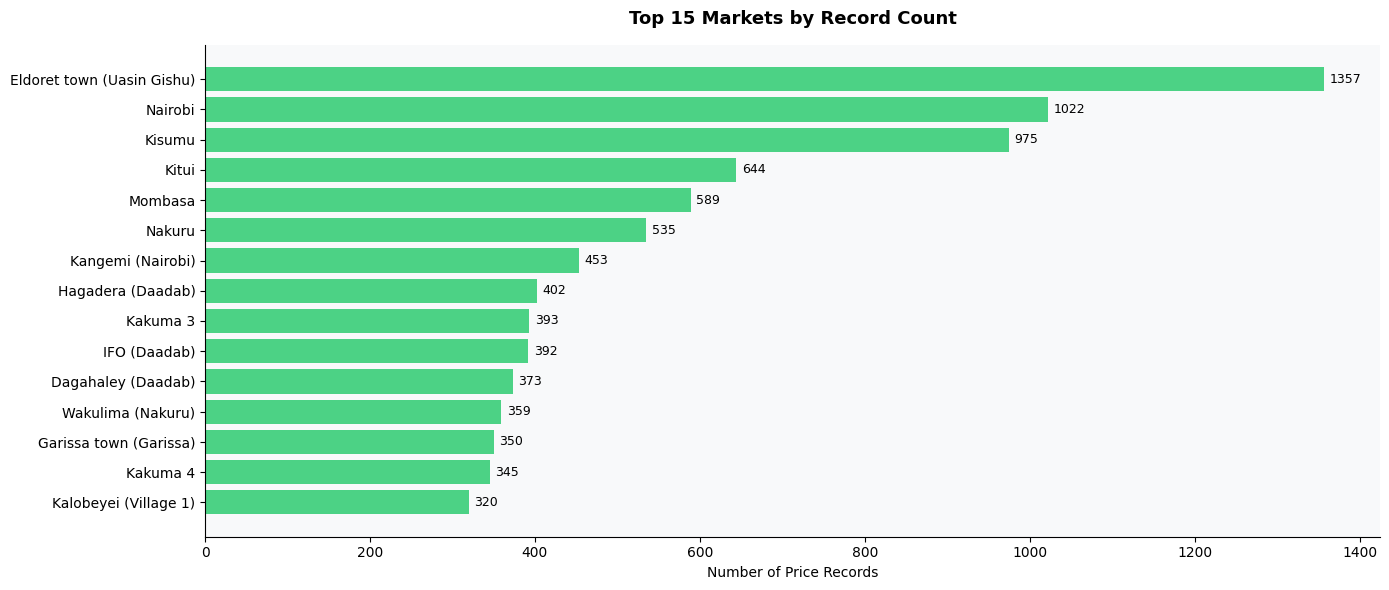

In [7]:
top_markets = df_target[MARKET_COL].value_counts().head(15)
fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(top_markets.index[::-1], top_markets.values[::-1], color=SP_GREEN, alpha=0.85)
ax.bar_label(bars, fmt='%d', padding=4, fontsize=9)
ax.set_xlabel('Number of Price Records')
ax.set_title('Top 15 Markets by Record Count', fontsize=13, fontweight='bold', pad=15)
ax.set_facecolor('#F8F9FA'); fig.patch.set_facecolor('white')
plt.tight_layout(); plt.savefig('viz1_markets.png', dpi=150, bbox_inches='tight'); plt.show()

### Viz 2 - Price Distribution per Commodity
Box plot showing median, spread, and outliers for each commodity's price.

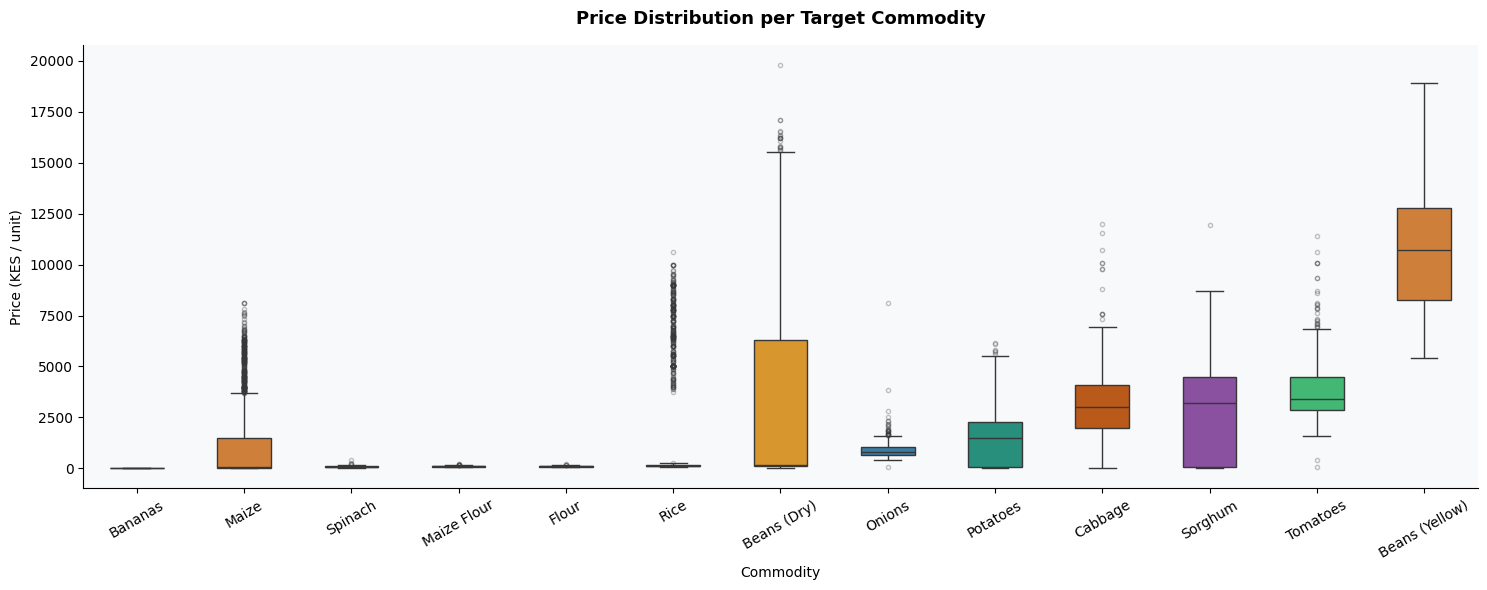

In [8]:
order = df_target.groupby('commodity_label')[PRICE_COL].median().sort_values().index.tolist()
fig, ax = plt.subplots(figsize=(15, 6))
sns.boxplot(data=df_target, x='commodity_label', y=PRICE_COL, order=order,
            palette=PALETTE[:len(order)], width=0.5,
            flierprops={'markersize': 3, 'alpha': 0.3}, ax=ax)
ax.set_title('Price Distribution per Target Commodity', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Commodity'); ax.set_ylabel('Price (KES / unit)')
ax.tick_params(axis='x', rotation=30)
ax.set_facecolor('#F8F9FA'); fig.patch.set_facecolor('white')
plt.tight_layout(); plt.savefig('viz2_boxplot.png', dpi=150, bbox_inches='tight'); plt.show()

### Viz 3 - Price Trends Over Time
Monthly median price per commodity, revealing long term trends and shocks.

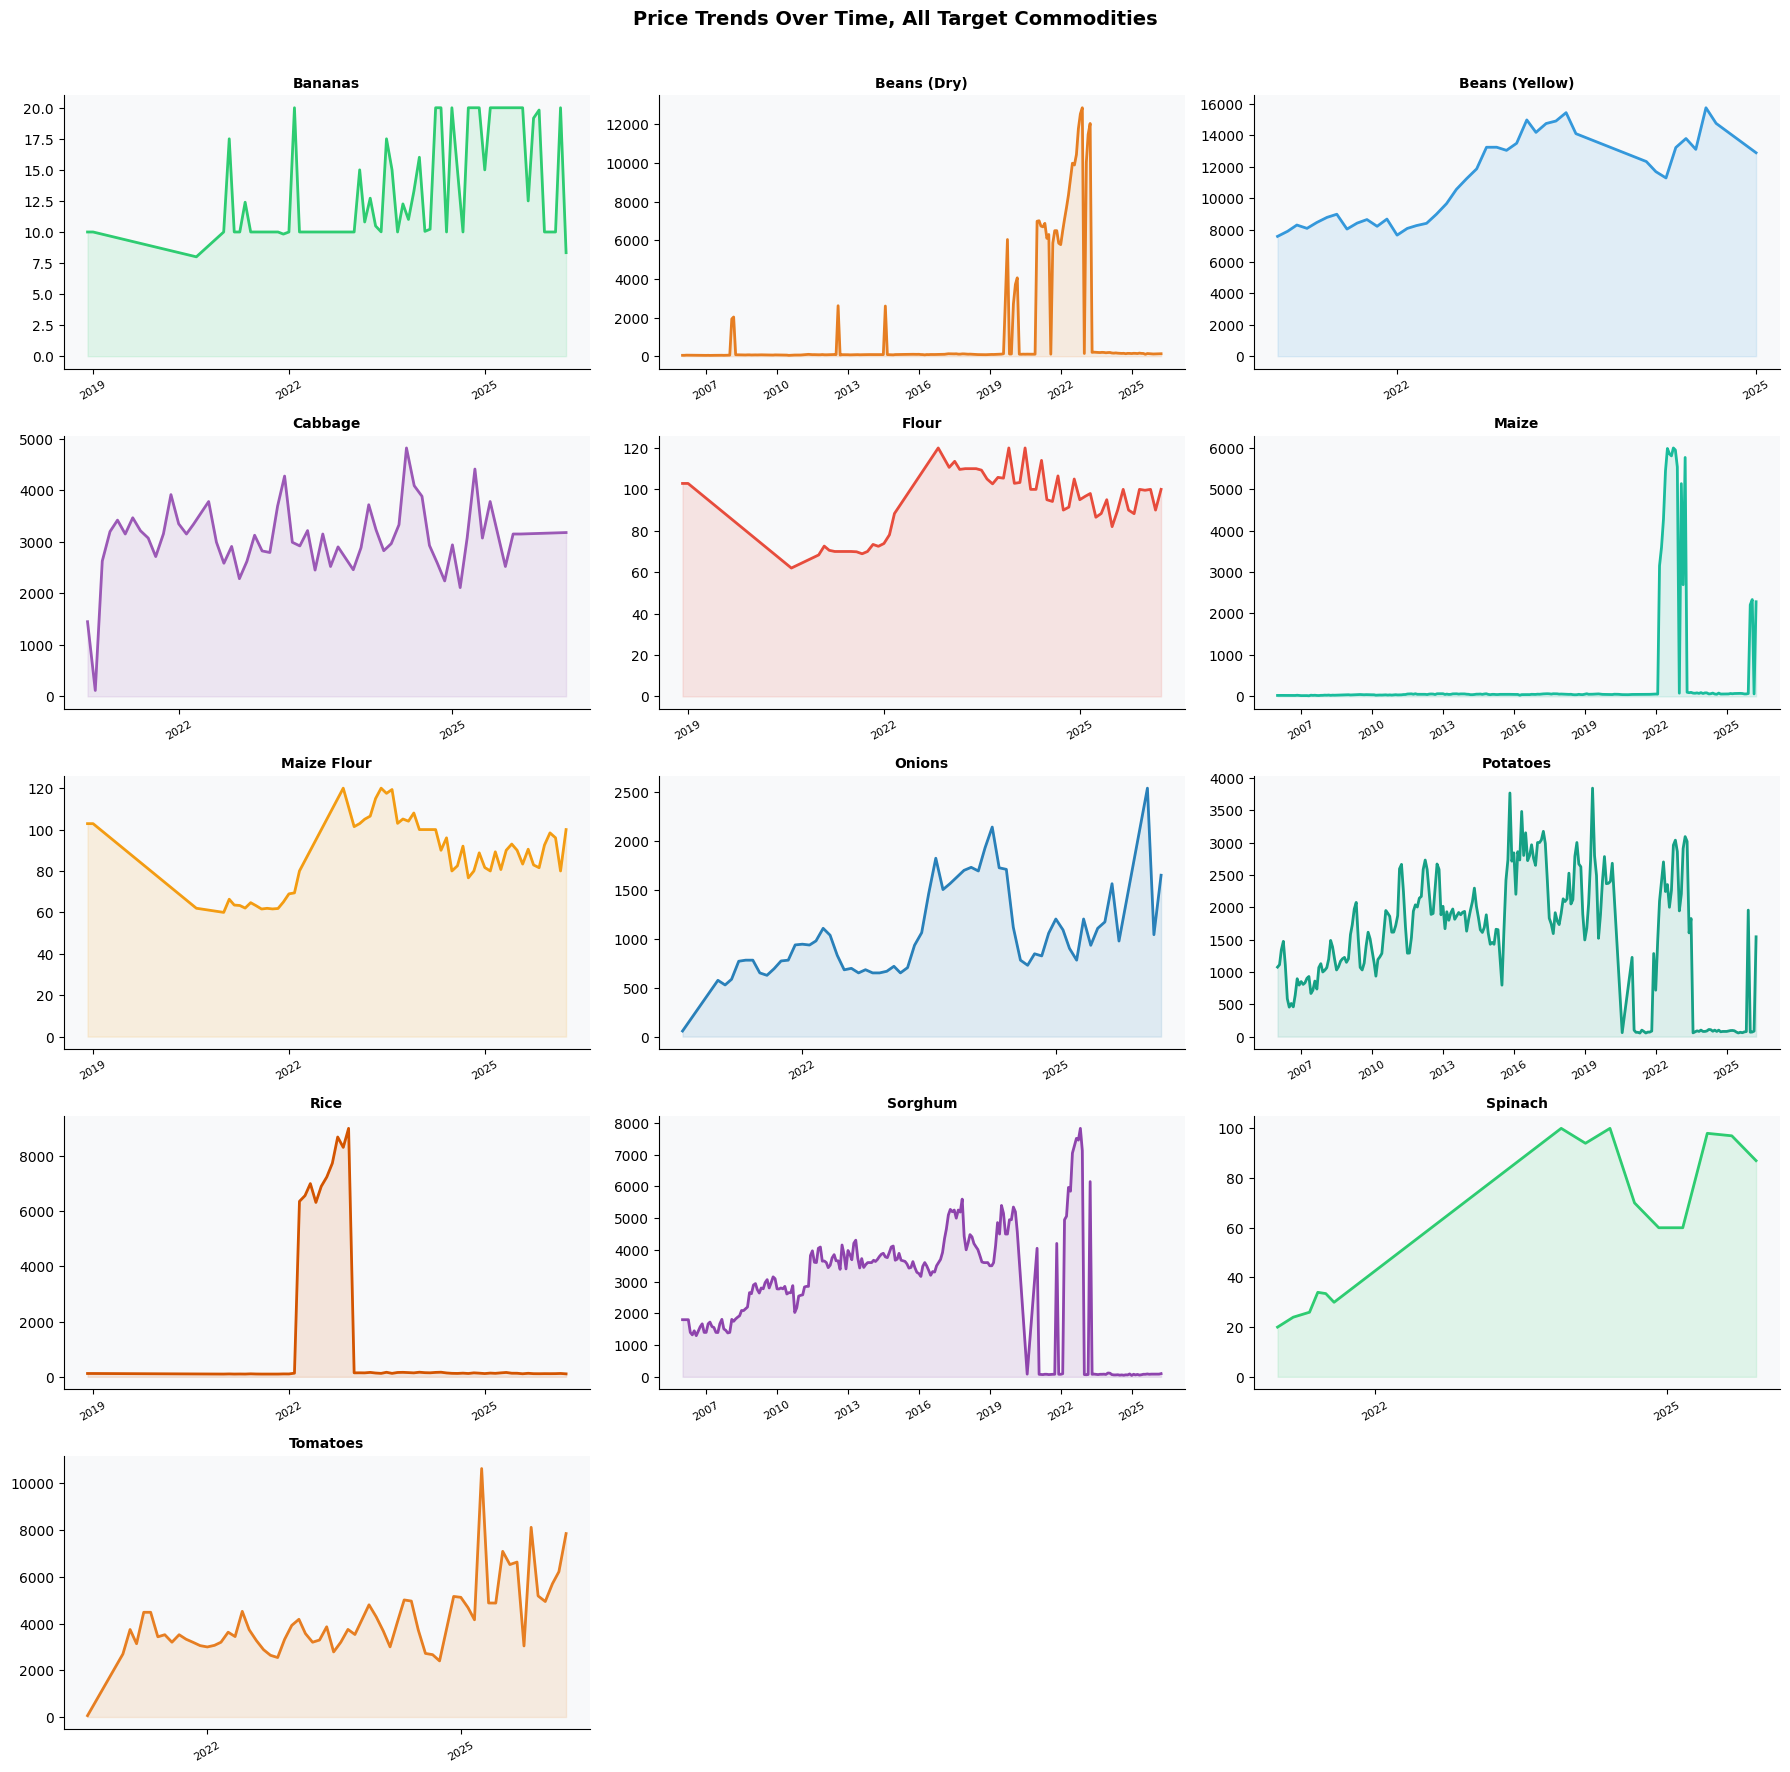

In [9]:
df_target['year_month'] = df_target[DATE_COL].dt.to_period('M')
monthly_avg = df_target.groupby(['year_month','commodity_label'])[PRICE_COL].median().reset_index()
monthly_avg['date'] = monthly_avg['year_month'].dt.to_timestamp()
commodities_list = sorted(monthly_avg['commodity_label'].unique())
ncols = 3; nrows = (len(commodities_list)+ncols-1)//ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 3.5*nrows))
axes = axes.flatten()
for i, comm in enumerate(commodities_list):
    data = monthly_avg[monthly_avg['commodity_label']==comm]
    color = PALETTE[i % len(PALETTE)]
    axes[i].plot(data['date'], data[PRICE_COL], color=color, linewidth=2)
    axes[i].fill_between(data['date'], data[PRICE_COL], alpha=0.12, color=color)
    axes[i].set_title(comm, fontsize=10, fontweight='bold')
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[i].xaxis.set_major_locator(mdates.YearLocator(3))
    axes[i].tick_params(axis='x', rotation=30, labelsize=8)
    axes[i].set_facecolor('#F8F9FA')
for j in range(i+1, len(axes)): axes[j].set_visible(False)
fig.suptitle('Price Trends Over Time, All Target Commodities', fontsize=14, fontweight='bold', y=1.01)
fig.patch.set_facecolor('white'); plt.tight_layout()
plt.savefig('viz3_trends.png', dpi=150, bbox_inches='tight'); plt.show()

### Viz 4 - Seasonal Price Index
Each commodity's price as a percent of its yearly average, by month. Reveals lean and harvest seasons.

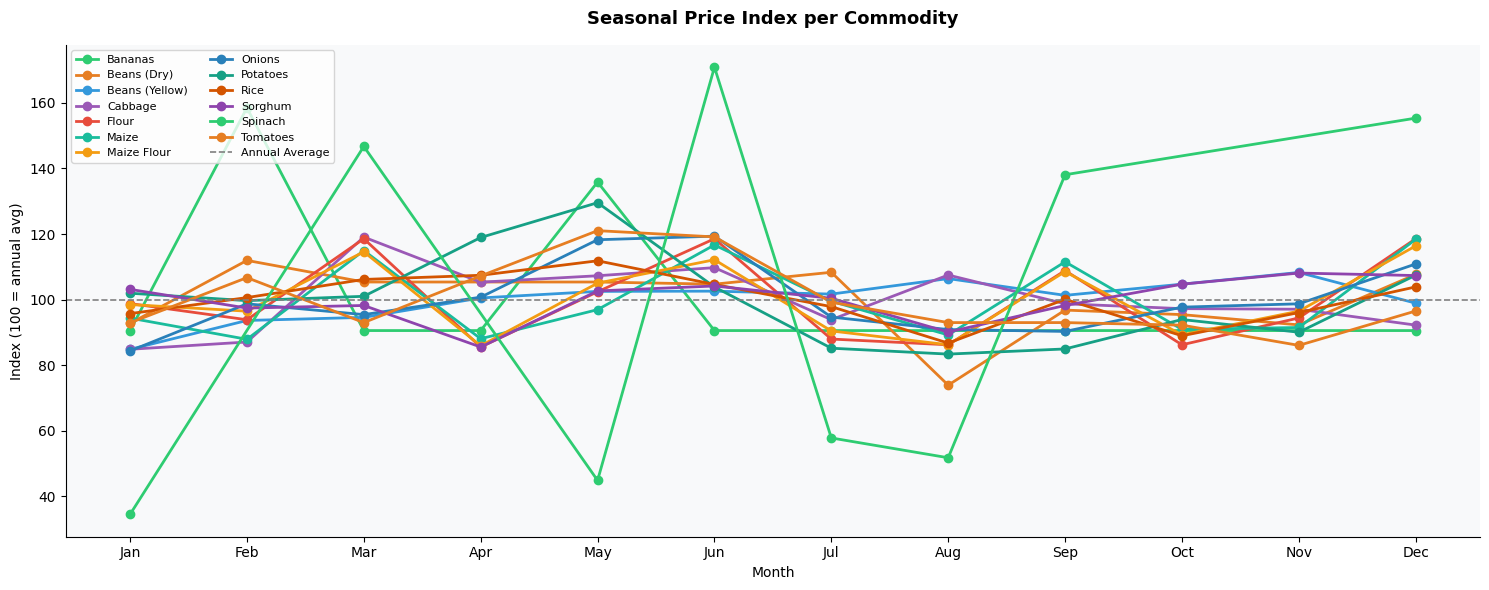

In [10]:
df_target['month'] = df_target[DATE_COL].dt.month
df_target['month_name'] = df_target[DATE_COL].dt.strftime('%b')
MONTH_ORDER = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
seasonal = df_target.groupby(['month','month_name','commodity_label'])[PRICE_COL].median().reset_index()
seasonal['month_name'] = pd.Categorical(seasonal['month_name'], categories=MONTH_ORDER, ordered=True)
seasonal = seasonal.sort_values(['commodity_label','month'])

fig, ax = plt.subplots(figsize=(15, 6))
for i, comm in enumerate(sorted(seasonal['commodity_label'].unique())):
    data = seasonal[seasonal['commodity_label']==comm].copy()
    mp = data[PRICE_COL].mean()
    if mp == 0: continue
    data['idx'] = (data[PRICE_COL] / mp) * 100
    ax.plot(data['month_name'], data['idx'], marker='o', linewidth=2, label=comm, color=PALETTE[i % len(PALETTE)])
ax.axhline(100, color='gray', linestyle='--', linewidth=1.2, label='Annual Average')
ax.set_title('Seasonal Price Index per Commodity', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Month'); ax.set_ylabel('Index (100 = annual avg)')
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.set_facecolor('#F8F9FA'); fig.patch.set_facecolor('white')
plt.tight_layout(); plt.savefig('viz4_seasonal.png', dpi=150, bbox_inches='tight'); plt.show()

### Viz 5 - Price Volatility
Coefficient of variation per commodity. Higher bars mean less predictable prices, where forecasting adds the most value.

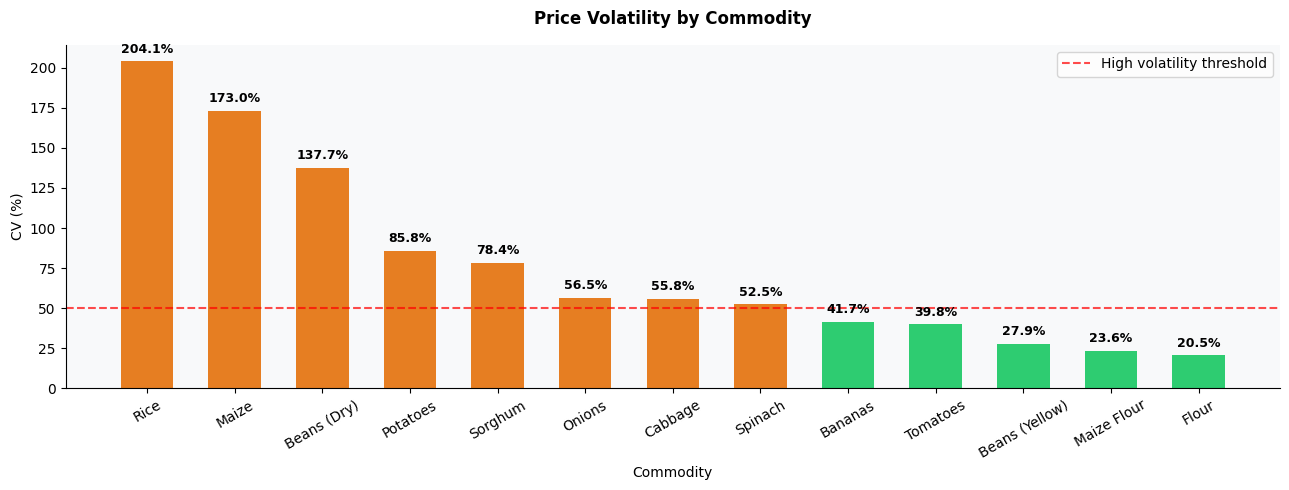

,commodity_label,mean_price,cv
9,Rice,1284.87,204.06
5,Maize,923.88,173.01
1,Beans (Dry),2929.32,137.70
8,Potatoes,1464.83,85.80
10,Sorghum,2852.66,78.38
7,Onions,909.35,56.54
3,Cabbage,3166.18,55.81
11,Spinach,82.87,52.45
0,Bananas,13.55,41.66
12,Tomatoes,3816.35,39.84


In [11]:
volatility = (df_target.groupby('commodity_label')[PRICE_COL]
              .agg(mean_price='mean', std_price='std')
              .assign(cv=lambda x: (x['std_price']/x['mean_price'])*100)
              .reset_index().sort_values('cv', ascending=False))
fig, ax = plt.subplots(figsize=(13, 5))
c_vol = [SP_ACCENT if v > 50 else SP_GREEN for v in volatility['cv']]
bars  = ax.bar(volatility['commodity_label'], volatility['cv'], color=c_vol, width=0.6)
ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=9, fontweight='bold')
ax.axhline(50, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='High volatility threshold')
ax.set_title('Price Volatility by Commodity', fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Commodity'); ax.set_ylabel('CV (%)')
ax.tick_params(axis='x', rotation=30); ax.legend()
ax.set_facecolor('#F8F9FA'); fig.patch.set_facecolor('white')
plt.tight_layout(); plt.savefig('viz5_volatility.png', dpi=150, bbox_inches='tight'); plt.show()
display(volatility[['commodity_label','mean_price','cv']].round(2))

### Viz 6 - Cross-Commodity Price Correlation
Shows whether commodities respond to the same market pressures.

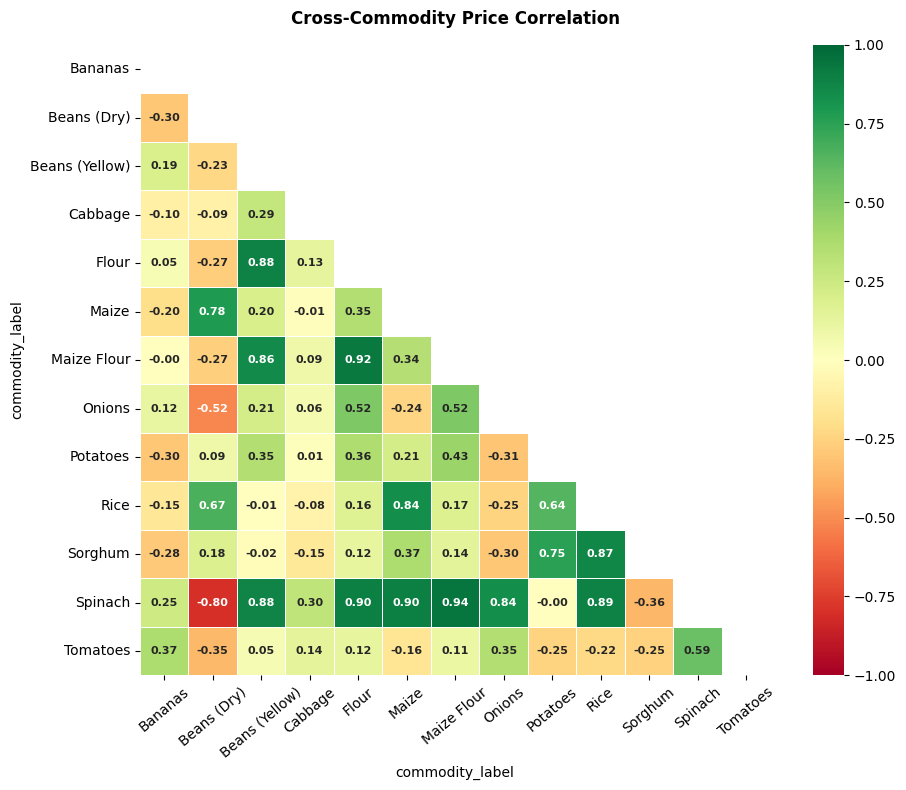

In [12]:
pivot = (df_target.groupby(['year_month','commodity_label'])[PRICE_COL]
         .median().unstack('commodity_label'))
pivot.index = pivot.index.to_timestamp()
pivot = pivot.dropna(how='all')
corr  = pivot.corr()
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            annot_kws={'size': 8, 'weight': 'bold'}, ax=ax)
ax.set_title('Cross-Commodity Price Correlation', fontsize=12, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=40); fig.patch.set_facecolor('white')
plt.tight_layout(); plt.savefig('viz6_correlation.png', dpi=150, bbox_inches='tight'); plt.show()

### Viz 7 - Inter-Market Price Comparison
Compares average price of the most common commodity across markets. Validates the market recommendation feature.

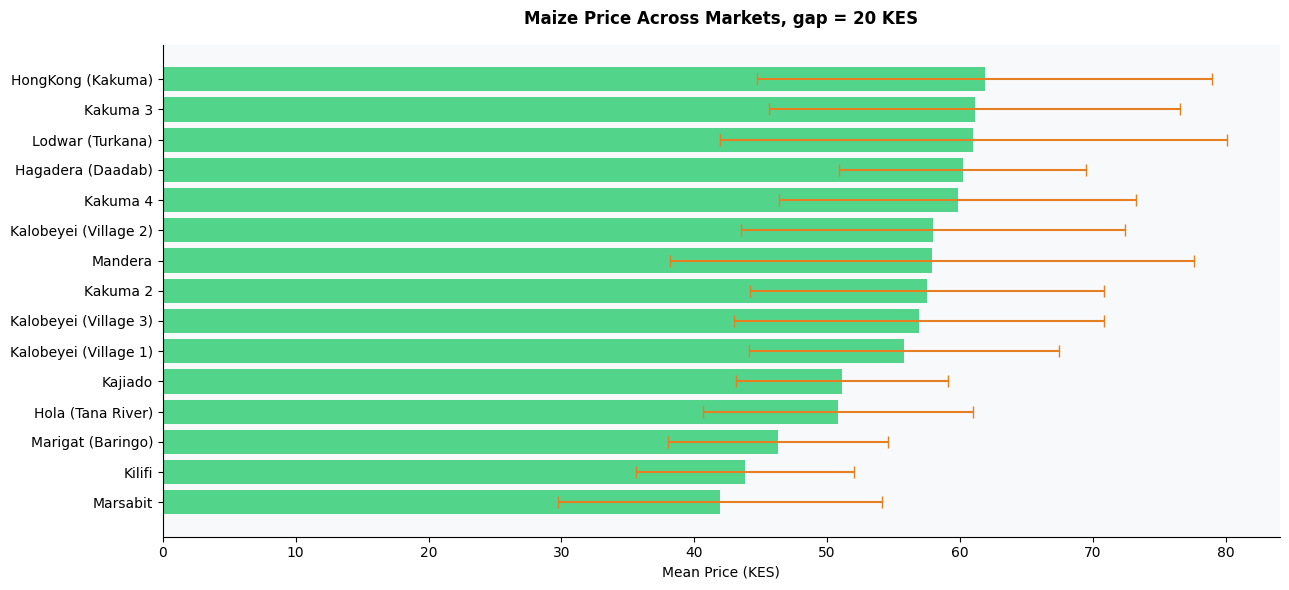

In [13]:
top_comm  = df_target['commodity_label'].value_counts().idxmax()
df_comm   = df_target[df_target['commodity_label']==top_comm].copy()
mkt_stats = (df_comm.groupby(MARKET_COL)[PRICE_COL]
             .agg(mean_price='mean', std_price='std', count='count').reset_index())
mkt_stats = mkt_stats[mkt_stats['count']>=15].sort_values('mean_price').head(15)
fig, ax = plt.subplots(figsize=(13, 6))
ax.barh(mkt_stats[MARKET_COL], mkt_stats['mean_price'],
        xerr=mkt_stats['std_price'], color=SP_GREEN, alpha=0.82,
        error_kw={'ecolor': SP_ACCENT, 'capsize': 4})
gap = mkt_stats['mean_price'].max() - mkt_stats['mean_price'].min()
ax.set_title(f'{top_comm} Price Across Markets, gap = {gap:.0f} KES', fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Mean Price (KES)'); ax.set_facecolor('#F8F9FA'); fig.patch.set_facecolor('white')
plt.tight_layout(); plt.savefig('viz7_market_comparison.png', dpi=150, bbox_inches='tight'); plt.show()

---
## Phase 4 - Data Cleaning

Steps: remove duplicates, handle outliers with a documented rule, confirm no
remaining nulls in key columns, and check class balance across commodities
and markets before proceeding.

In [14]:
print('Rows before cleaning:', len(df_target))

before = len(df_target)
df_clean = df_target.drop_duplicates(subset=[DATE_COL, MARKET_COL, COMM_COL, PRICE_COL]).copy()
print(f'Removed {before - len(df_clean)} exact duplicate rows')

def cap_outliers(group):
    mean, std = group[PRICE_COL].mean(), group[PRICE_COL].std()
    lower, upper = mean - 3*std, mean + 3*std
    return group[(group[PRICE_COL] >= lower) & (group[PRICE_COL] <= upper)]

before = len(df_clean)
df_clean = df_clean.groupby('commodity_label', group_keys=False).apply(cap_outliers)
print(f'Removed {before - len(df_clean)} rows beyond 3 standard deviations within their commodity group')

key_cols = [DATE_COL, MARKET_COL, COMM_COL, PRICE_COL, 'commodity_label']
null_check = df_clean[key_cols].isnull().sum()
print()
print('Null check on key columns:')
print(null_check.to_string())
assert null_check.sum() == 0, 'Nulls remain in key columns, investigate before continuing'

print()
print(f'Rows after cleaning: {len(df_clean):,}')

Rows before cleaning: 17944
Removed 0 exact duplicate rows
Removed 178 rows beyond 3 standard deviations within their commodity group

Null check on key columns:
date               0
market             0
commodity          0
price              0
commodity_label    0

Rows after cleaning: 17,766


### Viz 8 - Class Balance Check
Confirms no commodity or market is so underrepresented that the model cannot learn its pattern.

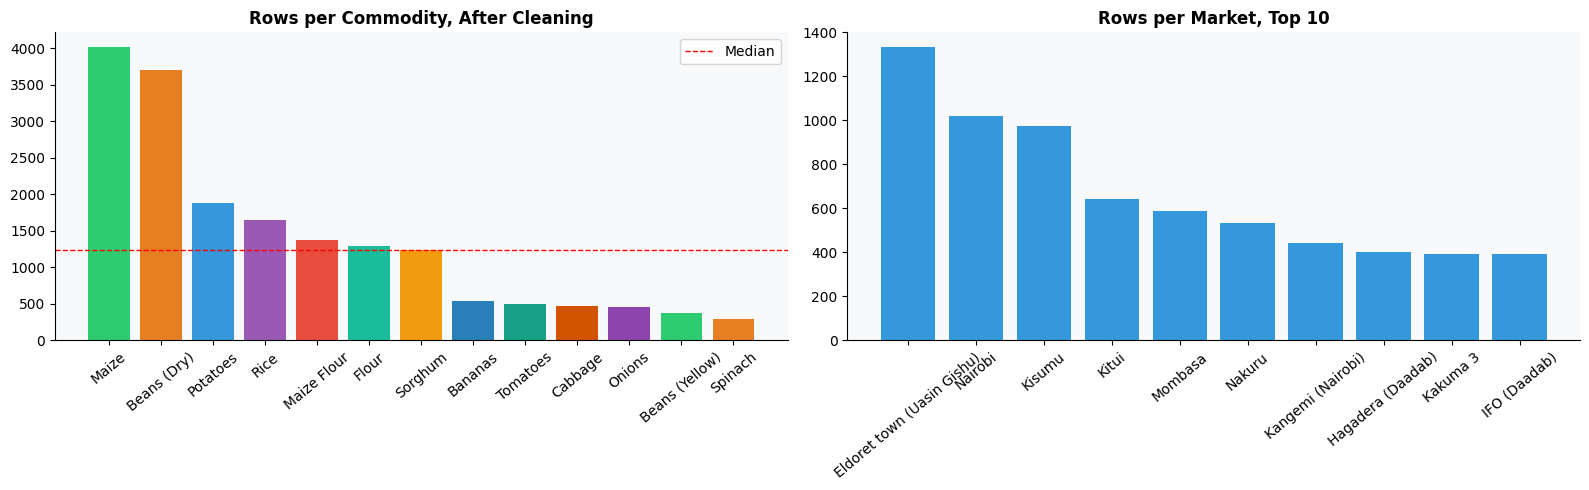

Smallest commodity group has 293 rows, judged sufficient to proceed


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

comm_counts = df_clean['commodity_label'].value_counts()
axes[0].bar(comm_counts.index, comm_counts.values, color=PALETTE[:len(comm_counts)])
axes[0].set_title('Rows per Commodity, After Cleaning', fontweight='bold')
axes[0].tick_params(axis='x', rotation=40)
axes[0].axhline(comm_counts.median(), color='red', linestyle='--', linewidth=1, label='Median')
axes[0].legend(); axes[0].set_facecolor('#F8F9FA')

market_counts = df_clean[MARKET_COL].value_counts().head(10)
axes[1].bar(market_counts.index, market_counts.values, color=SP_BLUE)
axes[1].set_title('Rows per Market, Top 10', fontweight='bold')
axes[1].tick_params(axis='x', rotation=40)
axes[1].set_facecolor('#F8F9FA')

fig.patch.set_facecolor('white'); plt.tight_layout()
plt.savefig('viz8_class_balance.png', dpi=150, bbox_inches='tight'); plt.show()

min_comm_count = comm_counts.min()
if min_comm_count < 100:
    print(f'Warning: {comm_counts.idxmin()} has only {min_comm_count} rows, may be too few to model reliably')
else:
    print(f'Smallest commodity group has {min_comm_count} rows, judged sufficient to proceed')

---
## Phase 5 - Feature Engineering and Labeling

Models understand numbers, not categories or dates directly, so every
feature here is built to be purely numeric. Each block below states what it
captures and why it is included.

In [16]:
df = df_clean.copy()
df = df.sort_values([COMM_COL, MARKET_COL, DATE_COL]).reset_index(drop=True)

# Temporal features capture calendar position, related to season and
# inflation drift over time.
df['year']        = df[DATE_COL].dt.year
df['month']       = df[DATE_COL].dt.month
df['quarter']     = df[DATE_COL].dt.quarter
df['day_of_year'] = df[DATE_COL].dt.dayofyear

# Plain month numbers treat December and January as far apart, 12 versus 1,
# when they are adjacent in real time. Sine and cosine encoding fixes this.
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

print('Temporal and cyclical features created')
df[['month', 'month_sin', 'month_cos']].drop_duplicates().sort_values('month')

Temporal and cyclical features created


,month,month_sin,month_cos
0,1,5.000000e-01,8.660254e-01
23,2,8.660254e-01,5.000000e-01
1,3,1.000000e+00,6.123234e-17
2,4,8.660254e-01,-5.000000e-01
13,5,5.000000e-01,-8.660254e-01
14,6,1.224647e-16,-1.000000e+00
15,7,-5.000000e-01,-8.660254e-01
3,8,-8.660254e-01,-5.000000e-01
4,9,-1.000000e+00,-1.836970e-16
5,10,-8.660254e-01,5.000000e-01


In [17]:
# Lag features capture recent price history. This is the single strongest
# predictor class for price forecasting, since prices rarely jump without
# warning.
grp = df.groupby([COMM_COL, MARKET_COL])[PRICE_COL]
for lag in [1, 2, 3, 6]:
    df[f'price_lag_{lag}'] = grp.shift(lag)

# Rolling statistics smooth short term noise and capture the recent trend
# level and volatility.
for w in [3, 6, 12]:
    df[f'rolling_mean_{w}'] = grp.transform(lambda x: x.shift(1).rolling(w, min_periods=1).mean())
    df[f'rolling_std_{w}']  = grp.transform(lambda x: x.shift(1).rolling(w, min_periods=1).std().fillna(0))

# Price change features capture momentum, whether the price has recently
# been rising or falling.
df['price_pct_change_1m'] = grp.pct_change(1).replace([np.inf, -np.inf], np.nan)
df['price_pct_change_3m'] = grp.pct_change(3).replace([np.inf, -np.inf], np.nan)

print('Lag, rolling, and momentum features created')

Lag, rolling, and momentum features created


In [18]:
le_comm   = LabelEncoder()
le_market = LabelEncoder()
df['commodity_enc'] = le_comm.fit_transform(df['commodity_label'])
df['market_enc']    = le_market.fit_transform(df[MARKET_COL].astype(str))

print('Commodity classes:', dict(zip(le_comm.classes_, range(len(le_comm.classes_)))))
print('Market classes:', dict(zip(le_market.classes_, range(len(le_market.classes_)))))

Commodity classes: {'Bananas': 0, 'Beans (Dry)': 1, 'Beans (Yellow)': 2, 'Cabbage': 3, 'Flour': 4, 'Maize': 5, 'Maize Flour': 6, 'Onions': 7, 'Potatoes': 8, 'Rice': 9, 'Sorghum': 10, 'Spinach': 11, 'Tomatoes': 12}
Market classes: {'Adele Center': 0, 'Alango Arba': 1, 'Alemsekon': 2, 'Alinjugur': 3, 'Alungu': 4, 'Amaya': 5, 'Aposta': 6, 'Archers Post': 7, 'Ashabito': 8, 'Bangale': 9, 'Bangladesh (Mombasa)': 10, 'Banissa': 11, 'Baragoi': 12, 'Baraki': 13, 'Benane': 14, 'Bilbil': 15, 'Biliqo': 16, 'Boji': 17, 'Boka': 18, 'Bulesa Bulesa': 19, 'Buna': 20, 'Bura': 21, 'Bute': 22, 'Charidende': 23, 'Chemolingot': 24, 'Dadaab town': 25, 'Dagahaley (Daadab)': 26, 'Damajale': 27, 'Dambala Fachana': 28, 'Dandora (Nairobi)': 29, 'Dertu': 30, 'Dirib': 31, 'Dub Goba': 32, 'Dzikunze': 33, 'El Wak': 34, 'Eldas': 35, 'Eldoret town (Uasin Gishu)': 36, 'Elelea': 37, 'Eliye Centre': 38, 'Emali': 39, 'Ethiopia (Kakuma)': 40, 'Garbatulla': 41, 'Garissa': 42, 'Garissa town (Garissa)': 43, 'Garsen': 44, 'Grif

In [19]:
FEATURE_COLS = [
    'year', 'month_sin', 'month_cos', 'quarter', 'day_of_year',
    'price_lag_1', 'price_lag_2', 'price_lag_3', 'price_lag_6',
    'rolling_mean_3', 'rolling_mean_6', 'rolling_mean_12',
    'rolling_std_3', 'rolling_std_6',
    'price_pct_change_1m', 'price_pct_change_3m',
    'commodity_enc', 'market_enc'
]
TARGET_COL = PRICE_COL

df_ml = df.dropna(subset=FEATURE_COLS + [TARGET_COL]).copy()
print(f'Feature engineering complete: {df_ml.shape[0]:,} rows x {len(FEATURE_COLS)} features')
print(f'Rows dropped due to lag and rolling NaNs: {len(df) - len(df_ml):,}')

Feature engineering complete: 11,662 rows x 18 features
Rows dropped due to lag and rolling NaNs: 6,104


### Viz 9 - Feature Correlation with Target Price
Confirms which engineered features the model is most likely to rely on, before any model is trained.

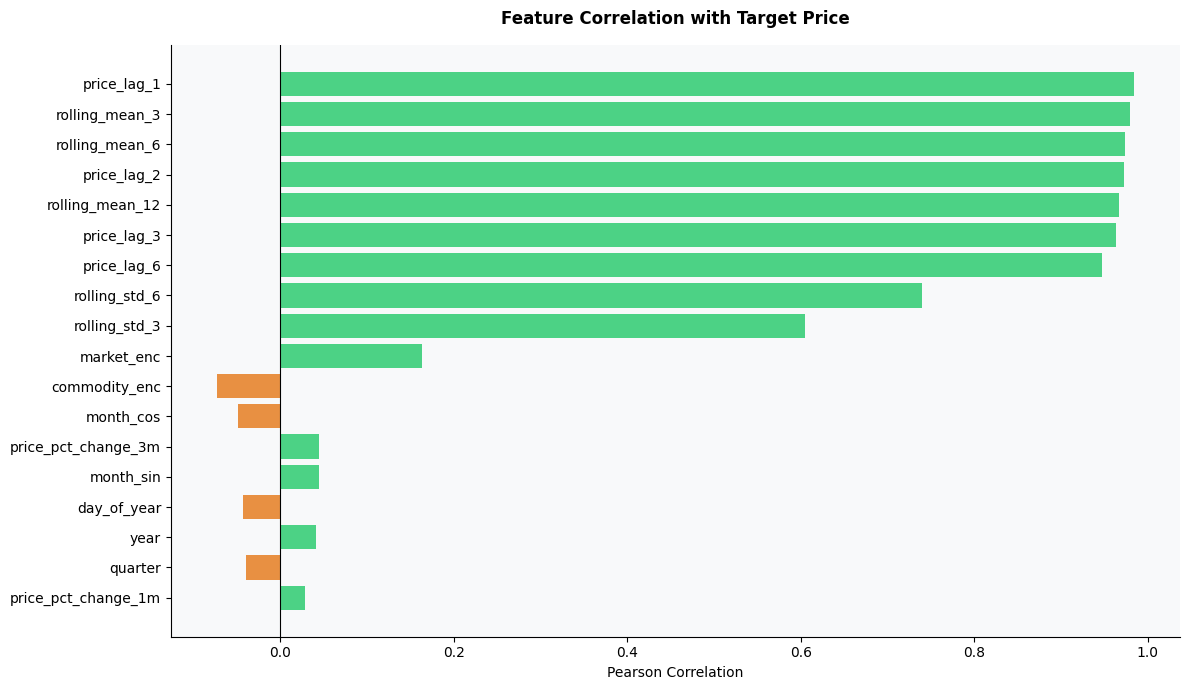

Top 5 features: ['price_lag_1', 'rolling_mean_3', 'rolling_mean_6', 'price_lag_2', 'rolling_mean_12']


In [20]:
corr_target = (df_ml[FEATURE_COLS + [TARGET_COL]].corr()[TARGET_COL]
               .drop(TARGET_COL).sort_values(key=abs, ascending=False))
fig, ax = plt.subplots(figsize=(12, 7))
colors_feat = [SP_GREEN if v > 0 else SP_ACCENT for v in corr_target.values]
ax.barh(corr_target.index[::-1], corr_target.values[::-1], color=colors_feat[::-1], alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Target Price', fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Pearson Correlation'); ax.set_facecolor('#F8F9FA')
fig.patch.set_facecolor('white'); plt.tight_layout()
plt.savefig('viz9_feature_correlation.png', dpi=150, bbox_inches='tight'); plt.show()
print('Top 5 features:', corr_target.head().index.tolist())

---
## Phase 6 - Data Normalization

Features here have very different scales. Year sits around 2020, price lags
range from tens to thousands of KES, and cyclical encodings sit between -1
and 1. Without scaling, models like Linear Regression, SVR, and the neural
networks would let large scale features dominate the loss simply due to
magnitude, not genuine importance.

Tree based models, namely Random Forest, XGBoost, and LightGBM, split on
feature thresholds and do not need scaling, but scaling is applied to all
model inputs uniformly here for a consistent and simpler pipeline. The
fitted scaler is saved so the same transform can be reapplied at inference
time.

In [21]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_all = df_ml[FEATURE_COLS].values
y_all = df_ml[TARGET_COL].values

print('Before scaling, feature ranges:')
for i, col in enumerate(FEATURE_COLS):
    print(f'  {col:25s} min={X_all[:,i].min():>10.2f}  max={X_all[:,i].max():>10.2f}')

Before scaling, feature ranges:
  year                      min=   2006.00  max=   2026.00
  month_sin                 min=     -1.00  max=      1.00
  month_cos                 min=     -1.00  max=      1.00
  quarter                   min=      1.00  max=      4.00
  day_of_year               min=     15.00  max=    350.00
  price_lag_1               min=      5.00  max=  18252.00
  price_lag_2               min=      5.00  max=  18252.00
  price_lag_3               min=      5.00  max=  18252.00
  price_lag_6               min=      5.00  max=  18252.00
  rolling_mean_3            min=      5.00  max=  17855.00
  rolling_mean_6            min=      5.00  max=  17227.45
  rolling_mean_12           min=      5.00  max=  16610.60
  rolling_std_3             min=      0.00  max=   6999.86
  rolling_std_6             min=      0.00  max=   4830.47
  price_pct_change_1m       min=     -0.99  max=     53.00
  price_pct_change_3m       min=     -0.99  max=     86.31
  commodity_enc         

### Viz 10 - Feature Scale Before Normalization
Shows why scaling matters. Some features span thousands of units, others span single digits.

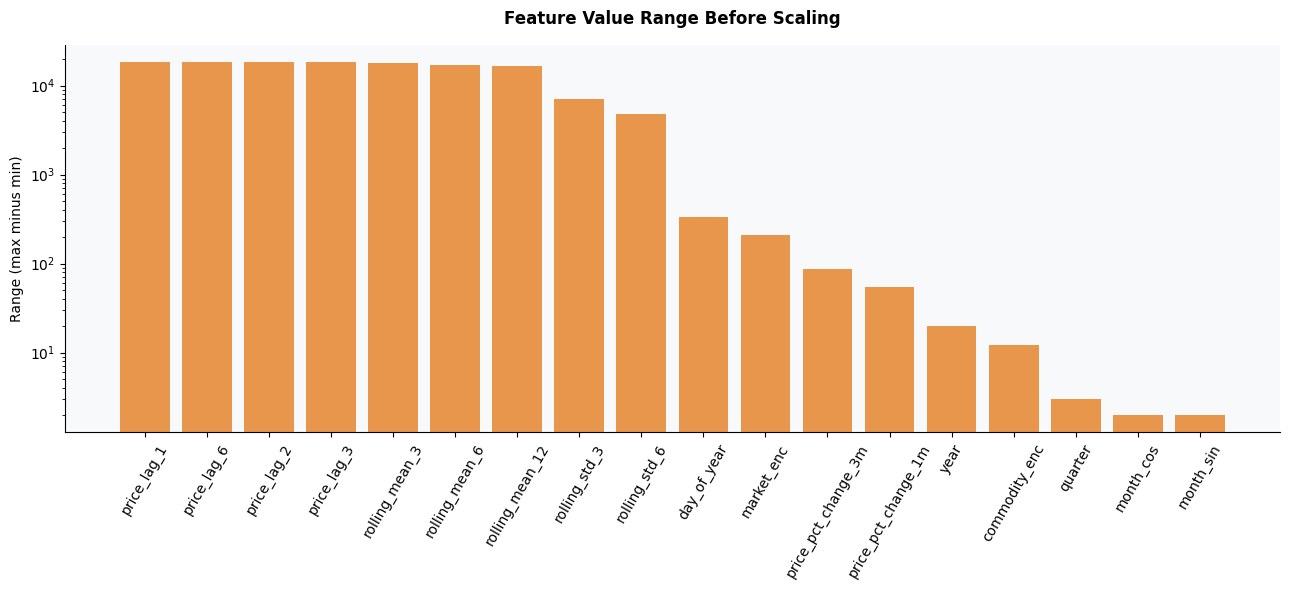

Log scale used because ranges differ by orders of magnitude across features


In [22]:
fig, ax = plt.subplots(figsize=(13, 6))
ranges = [X_all[:,i].max() - X_all[:,i].min() for i in range(len(FEATURE_COLS))]
order_idx = np.argsort(ranges)[::-1]
sorted_cols = [FEATURE_COLS[i] for i in order_idx]
sorted_ranges = [ranges[i] for i in order_idx]
bars = ax.bar(sorted_cols, sorted_ranges, color=SP_ACCENT, alpha=0.8)
ax.set_title('Feature Value Range Before Scaling', fontsize=12, fontweight='bold', pad=15)
ax.set_ylabel('Range (max minus min)'); ax.tick_params(axis='x', rotation=60)
ax.set_yscale('log')
ax.set_facecolor('#F8F9FA'); fig.patch.set_facecolor('white')
plt.tight_layout(); plt.savefig('viz10_scale_before.png', dpi=150, bbox_inches='tight'); plt.show()
print('Log scale used because ranges differ by orders of magnitude across features')

---
## Phase 7 - Train / Validation / Test Split

A three way split is used instead of a simple train test split. The
validation set supports honest hyperparameter selection. Tuning against the
test set would leak test information into model choices and inflate the
final reported score. The test set is touched only once, at the very end,
for final reporting.

The split is temporal, not random, since this is a time series problem.
Random splitting would let the model see future prices during training,
which does not reflect how the model will be used in production.

Split ratio: 70 percent train, 15 percent validation, 15 percent test, in
chronological order.

In [23]:
df_ml = df_ml.sort_values(DATE_COL).reset_index(drop=True)

n = len(df_ml)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_df = df_ml.iloc[:train_end]
val_df   = df_ml.iloc[train_end:val_end]
test_df  = df_ml.iloc[val_end:]

X_train_raw = train_df[FEATURE_COLS].values
y_train_raw = train_df[TARGET_COL].values
X_val_raw   = val_df[FEATURE_COLS].values
y_val_raw   = val_df[TARGET_COL].values
X_test_raw  = test_df[FEATURE_COLS].values
y_test_raw  = test_df[TARGET_COL].values

# Scaler fit on training data only, to avoid leaking validation or test
# distribution information into the transform.
X_train = scaler_X.fit_transform(X_train_raw)
X_val   = scaler_X.transform(X_val_raw)
X_test  = scaler_X.transform(X_test_raw)

y_train_sc = scaler_y.fit_transform(y_train_raw.reshape(-1,1)).ravel()
y_val_sc   = scaler_y.transform(y_val_raw.reshape(-1,1)).ravel()
y_test_sc  = scaler_y.transform(y_test_raw.reshape(-1,1)).ravel()

# Unscaled targets kept for tree models and for computing metrics in KES.
y_train = y_train_raw
y_val   = y_val_raw
y_test  = y_test_raw

print(f'Train      : {len(train_df):,} rows | {train_df[DATE_COL].min().date()} to {train_df[DATE_COL].max().date()}')
print(f'Validation : {len(val_df):,} rows | {val_df[DATE_COL].min().date()} to {val_df[DATE_COL].max().date()}')
print(f'Test       : {len(test_df):,} rows | {test_df[DATE_COL].min().date()} to {test_df[DATE_COL].max().date()}')

joblib.dump(scaler_X, 'scaler_X.pkl')
joblib.dump(scaler_y, 'scaler_y.pkl')
print()
print('Scalers fit on training data only, saved for inference reuse')

Train      : 8,163 rows | 2006-07-15 to 2023-02-15
Validation : 1,749 rows | 2023-02-15 to 2024-06-15
Test       : 1,750 rows | 2024-06-15 to 2026-04-15

Scalers fit on training data only, saved for inference reuse


In [24]:
# Save the raw splits and the scaled arrays, for reproducibility and reuse
# without re-running the cleaning and feature engineering pipeline.
train_df.to_csv('train_data.csv', index=False)
val_df.to_csv('val_data.csv', index=False)
test_df.to_csv('test_data.csv', index=False)

np.savez(
    'scaled_splits.npz',
    X_train=X_train, y_train_sc=y_train_sc, y_train=y_train,
    X_val=X_val,     y_val_sc=y_val_sc,     y_val=y_val,
    X_test=X_test,   y_test_sc=y_test_sc,   y_test=y_test
)

print('Saved splits:')
print('  train_data.csv, val_data.csv, test_data.csv, with all original columns')
print('  scaled_splits.npz, the scaled arrays used directly by the models')

Saved splits:
  train_data.csv, val_data.csv, test_data.csv, with all original columns
  scaled_splits.npz, the scaled arrays used directly by the models


### Viz 11 - Split Visualization
Confirms the three way split is chronological and non-overlapping.

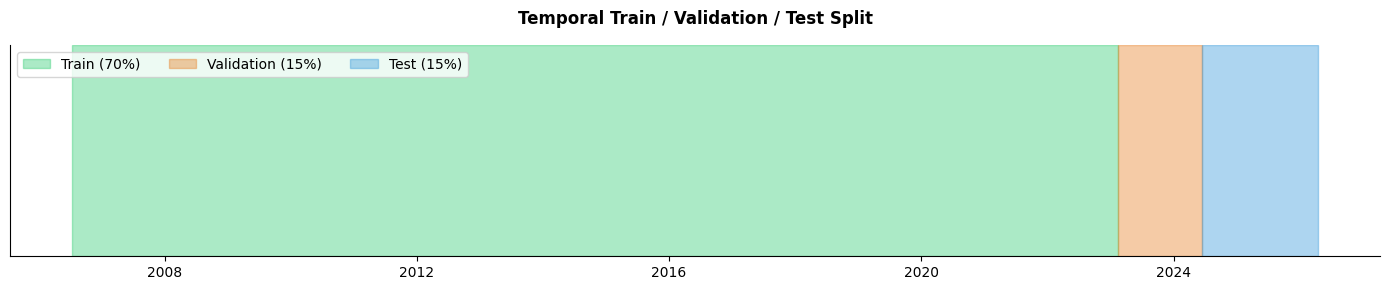

In [25]:
fig, ax = plt.subplots(figsize=(14, 3))
ax.axvspan(train_df[DATE_COL].min(), train_df[DATE_COL].max(), color=SP_GREEN, alpha=0.4, label='Train (70%)')
ax.axvspan(val_df[DATE_COL].min(), val_df[DATE_COL].max(), color=SP_ACCENT, alpha=0.4, label='Validation (15%)')
ax.axvspan(test_df[DATE_COL].min(), test_df[DATE_COL].max(), color=SP_BLUE, alpha=0.4, label='Test (15%)')
ax.set_yticks([])
ax.set_title('Temporal Train / Validation / Test Split', fontsize=12, fontweight='bold', pad=15)
ax.legend(loc='upper left', ncol=3)
fig.patch.set_facecolor('white'); plt.tight_layout()
plt.savefig('viz11_split.png', dpi=150, bbox_inches='tight'); plt.show()

---
## Phase 8 - Classical Models

Each model is trained on the training set and checked against the
validation set. None are evaluated on the test set until Phase 12. This
keeps the test set's role honest, a final, single use check.

In [26]:
def evaluate(name, y_true, y_pred, split_name='Validation'):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    print(f'  [{split_name}] MAE={mae:.3f} KES | RMSE={rmse:.3f} KES | R2={r2:.4f} | MAPE={mape:.2f}%')
    return {'Model': name, 'Split': split_name, 'MAE': round(mae,3), 'RMSE': round(rmse,3),
            'R2': round(r2,4), 'MAPE (%)': round(mape,2)}

val_results  = []
test_results = []
fitted_models = {}
print('Evaluation helper ready')

Evaluation helper ready


### Model 1 - Linear Regression
Baseline. Fits y = Xb plus e by least squares. No hidden layers.

In [27]:
print('Training Linear Regression...')
lr = LinearRegression()
lr.fit(X_train, y_train_sc)

y_pred_val_sc = lr.predict(X_val)
y_pred_val = np.clip(scaler_y.inverse_transform(y_pred_val_sc.reshape(-1,1)).ravel(), 0, None)

val_results.append(evaluate('Linear Regression', y_val, y_pred_val))
fitted_models['Linear Regression'] = lr
joblib.dump(lr, 'model_lr.pkl')

Training Linear Regression...
  [Validation] MAE=262.210 KES | RMSE=661.199 KES | R2=0.9705 | MAPE=65.94%


['model_lr.pkl']

### Model 2 - Random Forest
Ensemble of 300 trees with bootstrap sampling. Scaling not required, but scaled inputs used for pipeline consistency.

In [28]:
print('Training Random Forest...')
rf = RandomForestRegressor(
    n_estimators=300, max_depth=None, min_samples_split=5,
    min_samples_leaf=2, max_features='sqrt', n_jobs=-1, random_state=42
)
rf.fit(X_train, y_train)

y_pred_val = rf.predict(X_val)
val_results.append(evaluate('Random Forest', y_val, y_pred_val))
fitted_models['Random Forest'] = rf
joblib.dump(rf, 'model_rf.pkl')

Training Random Forest...
  [Validation] MAE=170.583 KES | RMSE=554.182 KES | R2=0.9793 | MAPE=15.87%


['model_rf.pkl']

### Model 3 - XGBoost
Sequential gradient boosting. Validation set used directly for early stopping.

In [29]:
print('Training XGBoost...')
xgb = XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
    reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1, verbosity=0
)
xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

y_pred_val = xgb.predict(X_val)
val_results.append(evaluate('XGBoost', y_val, y_pred_val))
fitted_models['XGBoost'] = xgb
joblib.dump(xgb, 'model_xgb.pkl')

Training XGBoost...
  [Validation] MAE=113.033 KES | RMSE=469.848 KES | R2=0.9851 | MAPE=9.28%


['model_xgb.pkl']

### Model 4 - LightGBM
Leaf wise gradient boosting, generally faster than XGBoost with comparable accuracy.

In [30]:
print('Training LightGBM...')
lgbm = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=-1, num_leaves=63,
    min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0, n_jobs=-1, random_state=42, verbose=-1
)
lgbm.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=-1)]
)

y_pred_val = lgbm.predict(X_val)
val_results.append(evaluate('LightGBM', y_val, y_pred_val))
fitted_models['LightGBM'] = lgbm
joblib.dump(lgbm, 'model_lgbm.pkl')

Training LightGBM...
  [Validation] MAE=114.964 KES | RMSE=465.059 KES | R2=0.9854 | MAPE=16.82%


['model_lgbm.pkl']

### Model 5 - SVR
RBF kernel maps features to a higher dimensional space before fitting a margin based regression.

In [31]:
print('Training SVR...')
svr = SVR(kernel='rbf', C=100, gamma=0.01, epsilon=0.01)
svr.fit(X_train, y_train_sc)

y_pred_val_sc = svr.predict(X_val)
y_pred_val = np.clip(scaler_y.inverse_transform(y_pred_val_sc.reshape(-1,1)).ravel(), 0, None)

val_results.append(evaluate('SVR (RBF)', y_val, y_pred_val))
fitted_models['SVR (RBF)'] = svr
joblib.dump(svr, 'model_svr.pkl')

Training SVR...
  [Validation] MAE=259.832 KES | RMSE=621.046 KES | R2=0.9740 | MAPE=92.46%


['model_svr.pkl']

---
## Phase 9 - Dense Neural Network Baseline

Architecture:
```
Input(18 features)
  Dense(64, relu, L2 regularization)
  BatchNormalization
  Dropout(0.2)
  Dense(32, relu)
  Dropout(0.2)
  Dense(1)

Loss: Huber | Optimizer: Adam(lr=0.001)
```

In [32]:
n_features = X_train.shape[1]

dense_baseline = Sequential([
    Input(shape=(n_features,)),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1)
], name='SokoPrice_Dense_Baseline')

dense_baseline.compile(optimizer=Adam(learning_rate=0.001), loss='huber', metrics=['mae'])
dense_baseline.summary()

I0000 00:00:1782284559.820107     197 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782284559.825608     197 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "SokoPrice_Dense_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,585 (14.00 KB)

 Trainable params: 3,457 (13.50 KB)

 Non-trainable params: 128 (512.00 B)

Training dense baseline...
Epoch 1/100


I0000 00:00:1782284562.229159     291 service.cc:152] XLA service 0x7cbf50012020 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782284562.229205     291 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782284562.229209     291 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782284562.609728     291 cuda_dnn.cc:529] Loaded cuDNN version 91002


 68/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2071 - mae: 0.4676

I0000 00:00:1782284564.444057     291 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


128/128 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 0.1023 - mae: 0.2885 - val_loss: 0.0404 - val_mae: 0.0925 - learning_rate: 0.0010
Epoch 2/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0348 - mae: 0.1295 - val_loss: 0.0323 - val_mae: 0.0829 - learning_rate: 0.0010
Epoch 3/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0243 - mae: 0.0860 - val_loss: 0.0233 - val_mae: 0.0646 - learning_rate: 0.0010
Epoch 4/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0195 - mae: 0.0659 - val_loss: 0.0183 - val_mae: 0.0507 - learning_rate: 0.0010
Epoch 5/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0166 - mae: 0.0557 - val_loss: 0.0148 - val_mae: 0.0410 - learning_rate: 0.0010
Epoch 6/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0141 - mae: 0.0496 - val_loss: 0.0130 - val_mae: 0.0371 - learning_rate: 0.0010
Epoch 7/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0123 - mae: 0.0468 - val_loss: 0.0114 - val_mae: 0.0346 - learning_rate: 0.0010
Epoch 8/10

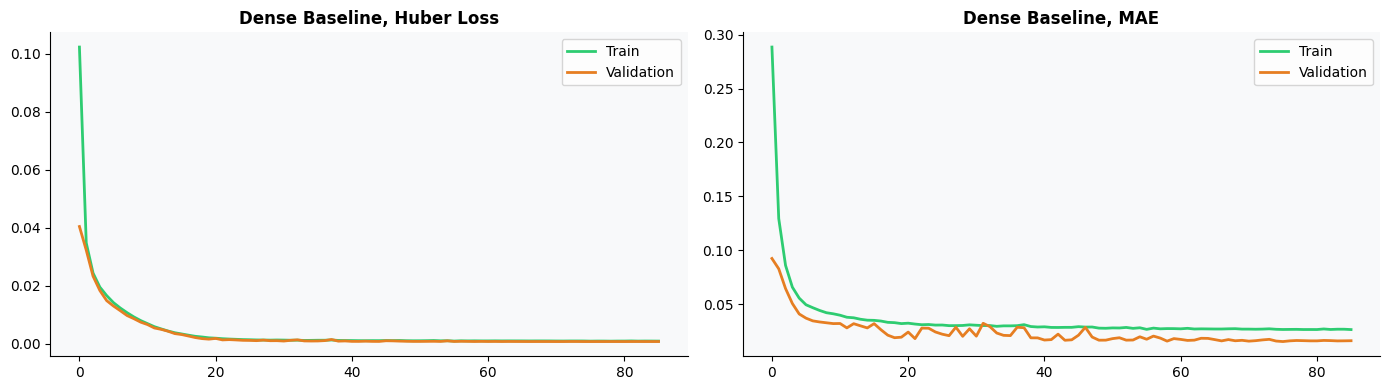

Stopped at epoch 86


In [33]:
print('Training dense baseline...')
callbacks = [
    EarlyStopping(patience=15, restore_best_weights=True, monitor='val_loss', verbose=0),
    ReduceLROnPlateau(patience=7, factor=0.5, min_lr=1e-5, verbose=0)
]

history_dense = dense_baseline.fit(
    X_train, y_train_sc,
    validation_data=(X_val, y_val_sc),
    epochs=100, batch_size=64, callbacks=callbacks, verbose=1
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_dense.history['loss'], label='Train', color=SP_GREEN, lw=2)
axes[0].plot(history_dense.history['val_loss'], label='Validation', color=SP_ACCENT, lw=2)
axes[0].set_title('Dense Baseline, Huber Loss', fontweight='bold')
axes[0].legend(); axes[0].set_facecolor('#F8F9FA')
axes[1].plot(history_dense.history['mae'], label='Train', color=SP_GREEN, lw=2)
axes[1].plot(history_dense.history['val_mae'], label='Validation', color=SP_ACCENT, lw=2)
axes[1].set_title('Dense Baseline, MAE', fontweight='bold')
axes[1].legend(); axes[1].set_facecolor('#F8F9FA')
fig.patch.set_facecolor('white'); plt.tight_layout()
plt.savefig('viz_dense_training.png', dpi=150, bbox_inches='tight'); plt.show()
print(f'Stopped at epoch {len(history_dense.history["loss"])}')

In [34]:
y_pred_val_sc = dense_baseline.predict(X_val, verbose=0).ravel()
y_pred_val = np.clip(scaler_y.inverse_transform(y_pred_val_sc.reshape(-1,1)).ravel(), 0, None)

val_results.append(evaluate('Dense Baseline', y_val, y_pred_val))
dense_baseline.save('model_dense_baseline.keras')

  [Validation] MAE=288.857 KES | RMSE=677.296 KES | R2=0.9691 | MAPE=76.55%


---
## Phase 10 - Hyperparameter Exploration

Hyperparameter search is run on the two strongest tree based candidates
from Phase 8, since they are fastest to retrain many times.
RandomizedSearchCV is used rather than a full grid search to keep runtime
reasonable. Each candidate is scored using 3 fold cross
validation within the training set only, so the validation and test sets
remain untouched by this search.

In [35]:
print('Searching XGBoost hyperparameters...')
xgb_param_grid = {
    'n_estimators':     [200, 300, 500],
    'learning_rate':    [0.01, 0.05, 0.1],
    'max_depth':        [4, 6, 8],
    'subsample':        [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
}
xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
    xgb_param_grid, n_iter=10, cv=3,
    scoring='neg_mean_absolute_error', random_state=42, n_jobs=-1, verbose=0
)
xgb_search.fit(X_train, y_train)
print('Best XGBoost parameters:')
for k, v in xgb_search.best_params_.items():
    print(f'  {k:20s} = {v}')
print(f'  CV MAE: {-xgb_search.best_score_:.3f} KES')

Searching XGBoost hyperparameters...
Best XGBoost parameters:
  subsample            = 0.8
  n_estimators         = 300
  max_depth            = 8
  learning_rate        = 0.1
  colsample_bytree     = 1.0
  CV MAE: 93.577 KES


In [36]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
print('Searching LightGBM hyperparameters...')
lgbm_param_grid = {
    'n_estimators':     [200, 300, 500],
    'learning_rate':    [0.01, 0.05, 0.1],
    'num_leaves':       [31, 63, 127],
    'subsample':        [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
}
lgbm_search = RandomizedSearchCV(
    lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
    lgbm_param_grid, n_iter=10, cv=3,
    scoring='neg_mean_absolute_error', random_state=42, n_jobs=-1, verbose=0
)
lgbm_search.fit(X_train, y_train)
print('Best LightGBM parameters:')
for k, v in lgbm_search.best_params_.items():
    print(f'  {k:20s} = {v}')
print(f'  CV MAE: {-lgbm_search.best_score_:.3f} KES')

Searching LightGBM hyperparameters...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12

Best LightGBM parameters:
  subsample            = 1.0
  num_leaves           = 63
  n_estimators         = 200
  learning_rate        = 0.05
  colsample_bytree     = 0.8
  CV MAE: 103.298 KES


In [37]:
best_xgb  = xgb_search.best_estimator_
best_lgbm = lgbm_search.best_estimator_

y_pred_val_xgb  = best_xgb.predict(X_val)
y_pred_val_lgbm = best_lgbm.predict(X_val)

val_results.append(evaluate('XGBoost (tuned)', y_val, y_pred_val_xgb))
val_results.append(evaluate('LightGBM (tuned)', y_val, y_pred_val_lgbm))

fitted_models['XGBoost (tuned)']  = best_xgb
fitted_models['LightGBM (tuned)'] = best_lgbm
joblib.dump(best_xgb, 'model_xgb_tuned.pkl')
joblib.dump(best_lgbm, 'model_lgbm_tuned.pkl')

  [Validation] MAE=116.798 KES | RMSE=479.376 KES | R2=0.9845 | MAPE=8.27%
  [Validation] MAE=118.934 KES | RMSE=474.774 KES | R2=0.9848 | MAPE=17.88%


['model_lgbm_tuned.pkl']

### Viz 12 - Hyperparameter Search Results
Shows how validation MAE changed across the sampled hyperparameter combinations.

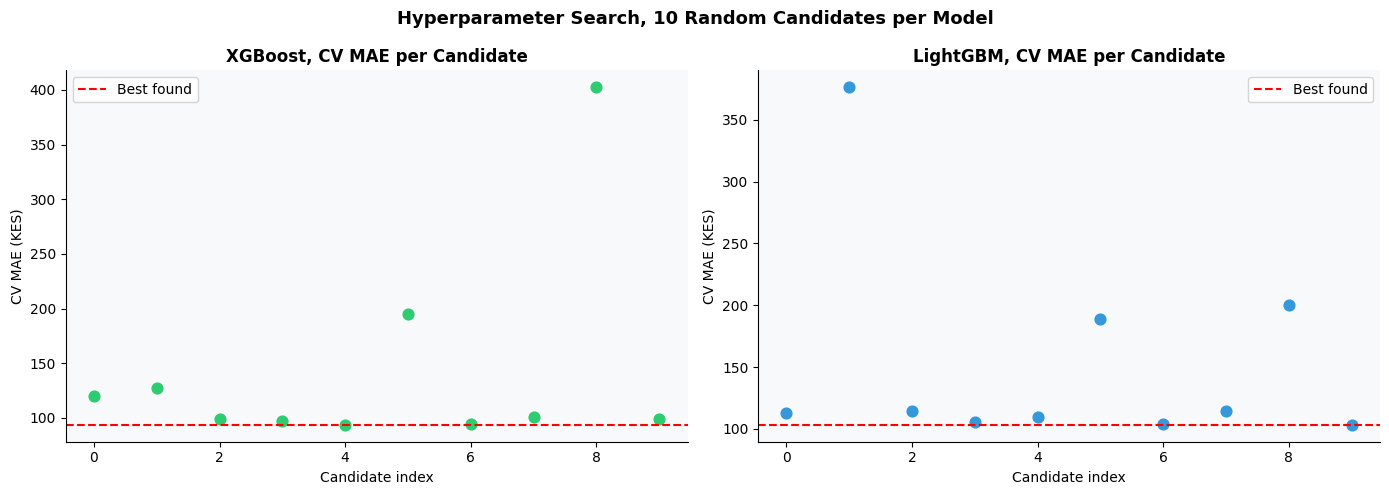

In [38]:
xgb_cv  = pd.DataFrame(xgb_search.cv_results_)
lgbm_cv = pd.DataFrame(lgbm_search.cv_results_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(range(len(xgb_cv)), -xgb_cv['mean_test_score'], color=SP_GREEN, s=60)
axes[0].axhline(-xgb_search.best_score_, color='red', linestyle='--', label='Best found')
axes[0].set_title('XGBoost, CV MAE per Candidate', fontweight='bold')
axes[0].set_xlabel('Candidate index'); axes[0].set_ylabel('CV MAE (KES)')
axes[0].legend(); axes[0].set_facecolor('#F8F9FA')

axes[1].scatter(range(len(lgbm_cv)), -lgbm_cv['mean_test_score'], color=SP_BLUE, s=60)
axes[1].axhline(-lgbm_search.best_score_, color='red', linestyle='--', label='Best found')
axes[1].set_title('LightGBM, CV MAE per Candidate', fontweight='bold')
axes[1].set_xlabel('Candidate index'); axes[1].set_ylabel('CV MAE (KES)')
axes[1].legend(); axes[1].set_facecolor('#F8F9FA')

fig.suptitle('Hyperparameter Search, 10 Random Candidates per Model', fontsize=13, fontweight='bold')
fig.patch.set_facecolor('white'); plt.tight_layout()
plt.savefig('viz12_hyperparam_search.png', dpi=150, bbox_inches='tight'); plt.show()

---
## Phase 11 - LSTM and GRU

LSTM and GRU exist specifically to capture dependencies across time steps.
Before building the full architectures, a direct question is checked: does
giving the model more history, a longer sequence window, actually improve
its forecasts, or does performance plateau or worsen once the window is too
long. This is the core idea behind these models, increasing or expanding
memory, and it is tested explicitly rather than assumed.

Sequences are built separately within each split so that no sequence
crosses a split boundary, which would otherwise leak future information
into training.

In [39]:
def make_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(seq_len, len(X)):
        Xs.append(X[i-seq_len:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

print('make_sequences function ready')

make_sequences function ready


### Memory Length Comparison

A lightweight GRU is trained across several sequence lengths and compared
on validation MAPE. A small model and a small number of epochs are used
deliberately here, since the goal is to compare the effect of memory
length, not to find the best possible model. The full sized LSTM and GRU
below then use whichever sequence length performs best in this comparison.

In [40]:
def build_probe_model(seq_len, n_feat):
    model = Sequential([
        Input(shape=(seq_len, n_feat)),
        GRU(32, return_sequences=False),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='huber')
    return model

SEQ_LENGTHS_TO_TEST = [3, 6, 12, 24]
memory_results = []

for seq_len in SEQ_LENGTHS_TO_TEST:
    print(f'Testing sequence length = {seq_len} months...')

    X_seq_tr_probe, y_seq_tr_probe = make_sequences(X_train, y_train_sc, seq_len)
    X_seq_val_probe, y_seq_val_probe = make_sequences(X_val, y_val_sc, seq_len)

    probe_model = build_probe_model(seq_len, X_train.shape[1])
    probe_model.fit(
        X_seq_tr_probe, y_seq_tr_probe,
        validation_data=(X_seq_val_probe, y_seq_val_probe),
        epochs=20, batch_size=64, verbose=0
    )

    y_pred_probe_sc = probe_model.predict(X_seq_val_probe, verbose=0).ravel()
    y_pred_probe = np.clip(scaler_y.inverse_transform(y_pred_probe_sc.reshape(-1,1)).ravel(), 0, None)
    y_val_probe_actual = scaler_y.inverse_transform(y_seq_val_probe.reshape(-1,1)).ravel()

    mape_probe = mean_absolute_percentage_error(y_val_probe_actual, y_pred_probe) * 100
    memory_results.append({'seq_len': seq_len, 'MAPE (%)': round(mape_probe, 2), 'n_sequences': len(y_seq_tr_probe)})
    print(f'  MAPE = {mape_probe:.2f}%  |  training sequences = {len(y_seq_tr_probe):,}')

memory_df = pd.DataFrame(memory_results)
print()
print(memory_df.to_string(index=False))

Testing sequence length = 3 months...
  MAPE = 2195.92%  |  training sequences = 8,160
Testing sequence length = 6 months...
  MAPE = 2763.94%  |  training sequences = 8,157
Testing sequence length = 12 months...
  MAPE = 1729.18%  |  training sequences = 8,151
Testing sequence length = 24 months...
  MAPE = 1672.07%  |  training sequences = 8,139

 seq_len  MAPE (%)  n_sequences
       3   2195.92         8160
       6   2763.94         8157
      12   1729.18         8151
      24   1672.07         8139


### Viz 13 - Effect of Sequence Length on Validation MAPE

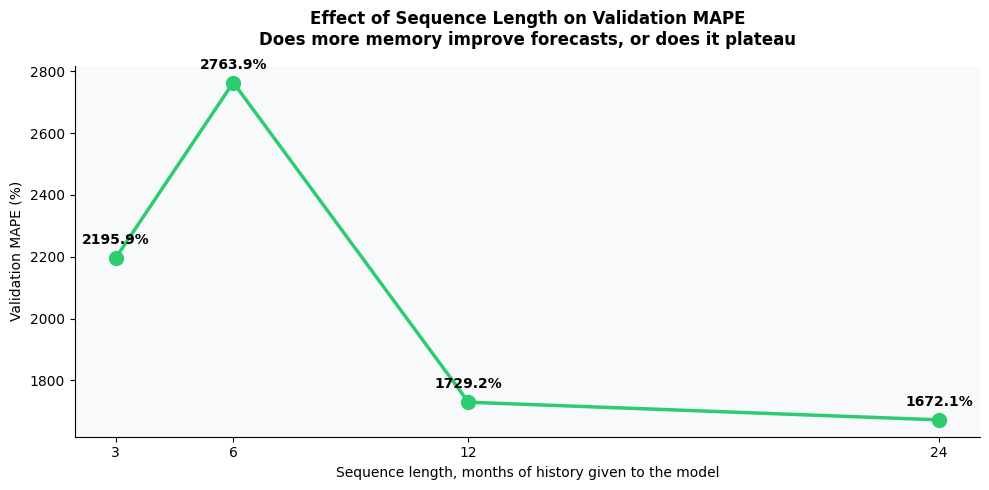

Best sequence length found: 24 months
This value is used for SEQ_LEN in the full LSTM and GRU models below.


In [41]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(memory_df['seq_len'], memory_df['MAPE (%)'], marker='o', markersize=10,
        linewidth=2.5, color=SP_GREEN)
for _, row in memory_df.iterrows():
    ax.annotate(f"{row['MAPE (%)']:.1f}%", (row['seq_len'], row['MAPE (%)']),
                textcoords='offset points', xytext=(0, 10), ha='center', fontsize=10, fontweight='bold')
ax.set_title('Effect of Sequence Length on Validation MAPE\nDoes more memory improve forecasts, or does it plateau', fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Sequence length, months of history given to the model')
ax.set_ylabel('Validation MAPE (%)')
ax.set_xticks(memory_df['seq_len'])
ax.set_facecolor('#F8F9FA'); fig.patch.set_facecolor('white')
plt.tight_layout(); plt.savefig('viz13_memory_length.png', dpi=150, bbox_inches='tight'); plt.show()

best_seq_len = int(memory_df.loc[memory_df['MAPE (%)'].idxmin(), 'seq_len'])
print(f'Best sequence length found: {best_seq_len} months')
print('This value is used for SEQ_LEN in the full LSTM and GRU models below.')

In [42]:
SEQ_LEN = best_seq_len

X_seq_train, y_seq_train = make_sequences(X_train, y_train_sc, SEQ_LEN)
X_seq_val,   y_seq_val   = make_sequences(X_val,   y_val_sc,   SEQ_LEN)
X_seq_test,  y_seq_test  = make_sequences(X_test,  y_test_sc,  SEQ_LEN)

print(f'Using SEQ_LEN = {SEQ_LEN} months for the full LSTM and GRU models')
print(f'Train sequences      : {X_seq_train.shape}')
print(f'Validation sequences : {X_seq_val.shape}')
print(f'Test sequences       : {X_seq_test.shape}')

Using SEQ_LEN = 24 months for the full LSTM and GRU models
Train sequences      : (8139, 24, 18)
Validation sequences : (1725, 24, 18)
Test sequences       : (1726, 24, 18)


In [43]:
# Verify the inverse transform round trips correctly before trusting any
# model prediction built on top of it. A scaling mismatch at this step is
# the most common reason recurrent models report abnormally large errors.
sample_scaled = y_seq_val[:5]
sample_unscaled = scaler_y.inverse_transform(sample_scaled.reshape(-1,1)).ravel()
sample_original = y_val[SEQ_LEN:SEQ_LEN+5]

print('Scaled targets:    ', np.round(sample_scaled, 4))
print('Inverse transformed:', np.round(sample_unscaled, 2))
print('Original KES values:', np.round(sample_original, 2))

max_diff = np.abs(sample_unscaled - sample_original).max()
print()
print(f'Max difference: {max_diff:.4f} KES')
assert max_diff < 0.5, 'Inverse transform does not match original values, stop and check scaler fitting'
print('Inverse transform verified correct, safe to proceed')

Scaled targets:     [0.7075 0.0069 0.0052 0.0036 0.1588]
Inverse transformed: [12915.     130.     100.      70.    2903.33]
Original KES values: [12915.     130.     100.      70.    2903.33]

Max difference: 0.0000 KES
Inverse transform verified correct, safe to proceed


### LSTM Architecture
```
Input (SEQ_LEN timesteps x 18 features)
  LSTM(64, return_sequences=True)
  Dropout(0.2)
  BatchNormalization
  LSTM(32, return_sequences=False)
  Dropout(0.2)
  Dense(16, relu)
  Dense(1)

Loss: Huber | Optimizer: Adam(lr=0.001)
```
Layer sizes kept at 64 and 32, matched to the dataset size, to reduce
overfitting risk on a relatively small sequence set.

In [44]:
n_feat = X_seq_train.shape[2]

lstm_model = Sequential([
    Input(shape=(SEQ_LEN, n_feat)),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    BatchNormalization(),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
], name='SokoPrice_LSTM')

lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='huber', metrics=['mae'])
lstm_model.summary()

Model: "SokoPrice_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        21,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,465 (134.63 KB)

 Trainable params: 34,337 (134.13 KB)

 Non-trainable params: 128 (512.00 B)

Training LSTM...
Epoch 1/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0185 - mae: 0.1426 - val_loss: 0.0207 - val_mae: 0.1367 - learning_rate: 0.0010
Epoch 2/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0115 - mae: 0.1171 - val_loss: 0.0226 - val_mae: 0.1718 - learning_rate: 0.0010
Epoch 3/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0111 - mae: 0.1161 - val_loss: 0.0233 - val_mae: 0.1732 - learning_rate: 0.0010
Epoch 4/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0108 - mae: 0.1148 - val_loss: 0.0214 - val_mae: 0.1569 - learning_rate: 0.0010
Epoch 5/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0106 - mae: 0.1145 - val_loss: 0.0209 - val_mae: 0.1526 - learning_rate: 0.0010
Epoch 6/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0106 - mae: 0.1149 - val_loss: 0.0215 - val_mae: 0.1590 - learning_rate: 0.0010
Epoch 7/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0105 - mae: 0.1143 - val_loss: 0.0236 - val_mae: 0.1756 - lea

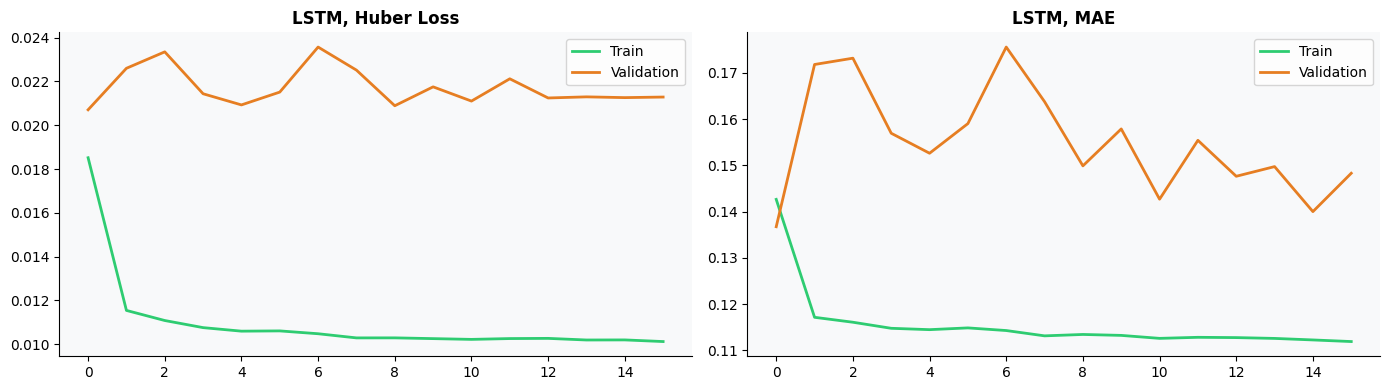

Stopped at epoch 16


In [45]:
print('Training LSTM...')
lstm_callbacks = [
    EarlyStopping(patience=15, restore_best_weights=True, monitor='val_loss', verbose=0),
    ReduceLROnPlateau(patience=7, factor=0.5, min_lr=1e-5, verbose=0)
]
history_lstm = lstm_model.fit(
    X_seq_train, y_seq_train,
    validation_data=(X_seq_val, y_seq_val),
    epochs=100, batch_size=64, callbacks=lstm_callbacks, verbose=1
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_lstm.history['loss'], label='Train', color=SP_GREEN, lw=2)
axes[0].plot(history_lstm.history['val_loss'], label='Validation', color=SP_ACCENT, lw=2)
axes[0].set_title('LSTM, Huber Loss', fontweight='bold')
axes[0].legend(); axes[0].set_facecolor('#F8F9FA')
axes[1].plot(history_lstm.history['mae'], label='Train', color=SP_GREEN, lw=2)
axes[1].plot(history_lstm.history['val_mae'], label='Validation', color=SP_ACCENT, lw=2)
axes[1].set_title('LSTM, MAE', fontweight='bold')
axes[1].legend(); axes[1].set_facecolor('#F8F9FA')
fig.patch.set_facecolor('white'); plt.tight_layout()
plt.savefig('viz_lstm_training.png', dpi=150, bbox_inches='tight'); plt.show()
print(f'Stopped at epoch {len(history_lstm.history["loss"])}')

In [46]:
y_pred_val_lstm_sc = lstm_model.predict(X_seq_val, verbose=0).ravel()
y_pred_val_lstm = np.clip(scaler_y.inverse_transform(y_pred_val_lstm_sc.reshape(-1,1)).ravel(), 0, None)
y_val_lstm_actual = scaler_y.inverse_transform(y_seq_val.reshape(-1,1)).ravel()

val_results.append(evaluate('LSTM', y_val_lstm_actual, y_pred_val_lstm))
lstm_model.save('model_lstm.keras')

  [Validation] MAE=2494.897 KES | RMSE=3713.003 KES | R2=0.0258 | MAPE=1797.16%


### GRU Architecture
```
Input (SEQ_LEN timesteps x 18 features)
  GRU(64, return_sequences=True)
  Dropout(0.2)
  BatchNormalization
  GRU(32, return_sequences=False)
  Dropout(0.2)
  Dense(16, relu)
  Dense(1)

Loss: Huber | Optimizer: Adam(lr=0.001)
```
Same sizing as LSTM for a fair comparison. GRU uses fewer gates than LSTM,
so it trains faster, which is checked below alongside accuracy.

In [47]:
gru_model = Sequential([
    Input(shape=(SEQ_LEN, n_feat)),
    GRU(64, return_sequences=True),
    Dropout(0.2),
    BatchNormalization(),
    GRU(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
], name='SokoPrice_GRU')

gru_model.compile(optimizer=Adam(learning_rate=0.001), loss='huber', metrics=['mae'])
gru_model.summary()

Model: "SokoPrice_GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_4 (GRU)                     │ (None, 24, 64)         │        16,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_5 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,337 (102.88 KB)

 Trainable params: 26,209 (102.38 KB)

 Non-trainable params: 128 (512.00 B)

Training GRU...
Epoch 1/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0262 - mae: 0.1739 - val_loss: 0.0222 - val_mae: 0.1204 - learning_rate: 0.0010
Epoch 2/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0137 - mae: 0.1282 - val_loss: 0.0210 - val_mae: 0.1355 - learning_rate: 0.0010
Epoch 3/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0122 - mae: 0.1208 - val_loss: 0.0210 - val_mae: 0.1389 - learning_rate: 0.0010
Epoch 4/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0116 - mae: 0.1182 - val_loss: 0.0210 - val_mae: 0.1406 - learning_rate: 0.0010
Epoch 5/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0111 - mae: 0.1160 - val_loss: 0.0213 - val_mae: 0.1437 - learning_rate: 0.0010
Epoch 6/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0110 - mae: 0.1159 - val_loss: 0.0210 - val_mae: 0.1440 - learning_rate: 0.0010
Epoch 7/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0107 - mae: 0.1147 - val_loss: 0.0211 - val_mae: 0.1383 - le

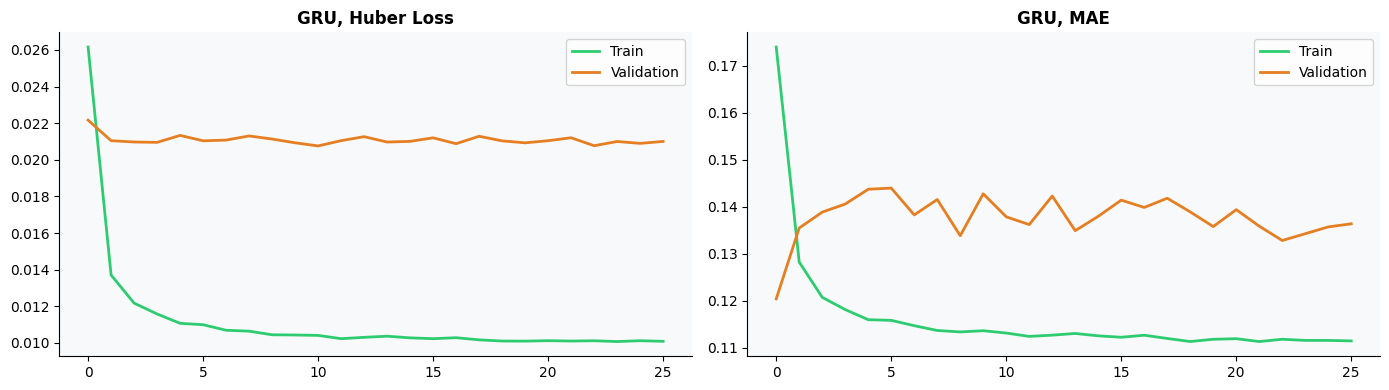

Stopped at epoch 26


In [48]:
print('Training GRU...')
gru_callbacks = [
    EarlyStopping(patience=15, restore_best_weights=True, monitor='val_loss', verbose=0),
    ReduceLROnPlateau(patience=7, factor=0.5, min_lr=1e-5, verbose=0)
]
history_gru = gru_model.fit(
    X_seq_train, y_seq_train,
    validation_data=(X_seq_val, y_seq_val),
    epochs=100, batch_size=64, callbacks=gru_callbacks, verbose=1
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_gru.history['loss'], label='Train', color=SP_GREEN, lw=2)
axes[0].plot(history_gru.history['val_loss'], label='Validation', color=SP_ACCENT, lw=2)
axes[0].set_title('GRU, Huber Loss', fontweight='bold')
axes[0].legend(); axes[0].set_facecolor('#F8F9FA')
axes[1].plot(history_gru.history['mae'], label='Train', color=SP_GREEN, lw=2)
axes[1].plot(history_gru.history['val_mae'], label='Validation', color=SP_ACCENT, lw=2)
axes[1].set_title('GRU, MAE', fontweight='bold')
axes[1].legend(); axes[1].set_facecolor('#F8F9FA')
fig.patch.set_facecolor('white'); plt.tight_layout()
plt.savefig('viz_gru_training.png', dpi=150, bbox_inches='tight'); plt.show()
print(f'Stopped at epoch {len(history_gru.history["loss"])}')

In [49]:
y_pred_val_gru_sc = gru_model.predict(X_seq_val, verbose=0).ravel()
y_pred_val_gru = np.clip(scaler_y.inverse_transform(y_pred_val_gru_sc.reshape(-1,1)).ravel(), 0, None)
y_val_gru_actual = scaler_y.inverse_transform(y_seq_val.reshape(-1,1)).ravel()

val_results.append(evaluate('GRU', y_val_gru_actual, y_pred_val_gru))
gru_model.save('model_gru.keras')

  [Validation] MAE=2515.301 KES | RMSE=3717.934 KES | R2=0.0232 | MAPE=1852.80%


---
## Phase 12 - Validation Comparison and Final Test Evaluation

All models are first compared on the validation set. The single best model
is then evaluated on the test set exactly once. This is the only test set
number reported as the final result, keeping the evaluation honest.

In [50]:
val_df_results = pd.DataFrame(val_results).sort_values('MAPE (%)')
print('='*70)
print('   VALIDATION SET RESULTS, ALL MODELS, SORTED BY MAPE')
print('='*70)
print(val_df_results.to_string(index=False))
print('='*70)

   VALIDATION SET RESULTS, ALL MODELS, SORTED BY MAPE
            Model      Split      MAE     RMSE     R2  MAPE (%)
  XGBoost (tuned) Validation  116.798  479.376 0.9845      8.27
          XGBoost Validation  113.033  469.848 0.9851      9.28
    Random Forest Validation  170.583  554.182 0.9793     15.87
         LightGBM Validation  114.964  465.059 0.9854     16.82
 LightGBM (tuned) Validation  118.934  474.774 0.9848     17.88
Linear Regression Validation  262.210  661.199 0.9705     65.94
   Dense Baseline Validation  288.857  677.296 0.9691     76.55
        SVR (RBF) Validation  259.832  621.046 0.9740     92.46
             LSTM Validation 2494.897 3713.003 0.0258   1797.16
              GRU Validation 2515.301 3717.934 0.0232   1852.80


### Viz 14 - Validation MAPE Across All Models

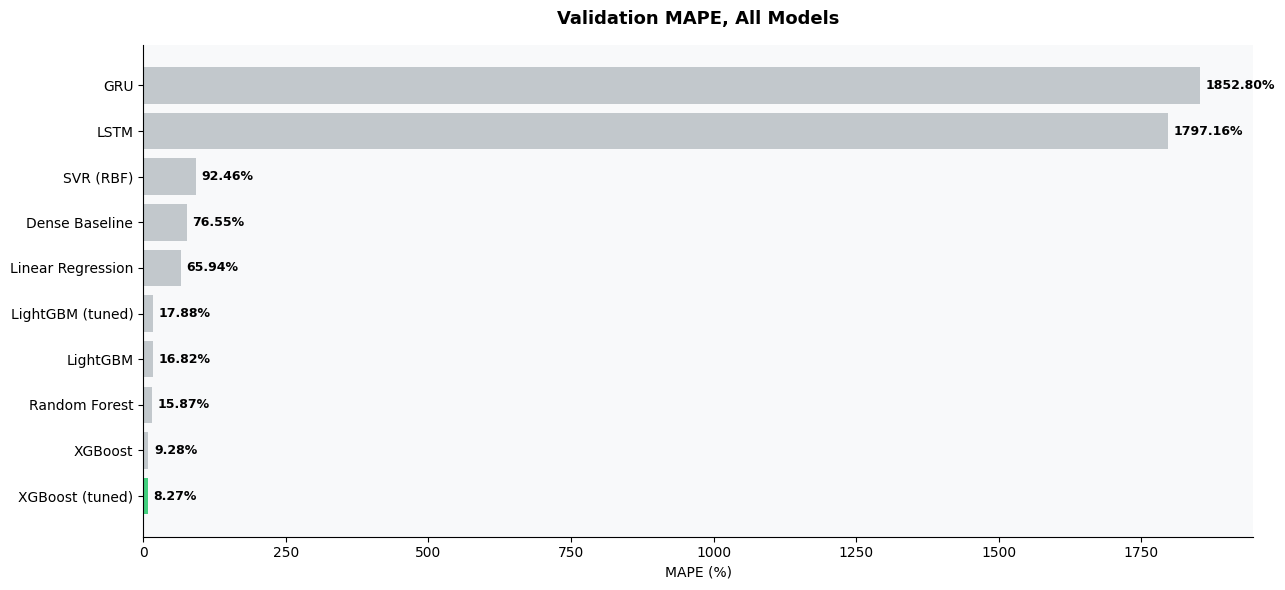

In [51]:
fig, ax = plt.subplots(figsize=(13, 6))
df_sorted = val_df_results.sort_values('MAPE (%)')
colors_v = [SP_GREEN if i==0 else '#BDC3C7' for i in range(len(df_sorted))]
bars = ax.barh(df_sorted['Model'], df_sorted['MAPE (%)'], color=colors_v, alpha=0.9)
ax.bar_label(bars, fmt='%.2f%%', padding=4, fontsize=9, fontweight='bold')
ax.set_title('Validation MAPE, All Models', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('MAPE (%)')
ax.set_facecolor('#F8F9FA'); fig.patch.set_facecolor('white')
plt.tight_layout(); plt.savefig('viz14_val_comparison.png', dpi=150, bbox_inches='tight'); plt.show()

In [52]:
best_model_name = val_df_results.iloc[0]['Model']
print(f'Best model on validation set: {best_model_name}')

Best model on validation set: XGBoost (tuned)


In [53]:
if best_model_name in ['LSTM', 'GRU']:
    model = lstm_model if best_model_name == 'LSTM' else gru_model
    y_pred_test_sc = model.predict(X_seq_test, verbose=0).ravel()
    y_pred_test = np.clip(scaler_y.inverse_transform(y_pred_test_sc.reshape(-1,1)).ravel(), 0, None)
    y_test_actual = scaler_y.inverse_transform(y_seq_test.reshape(-1,1)).ravel()
elif best_model_name == 'Dense Baseline':
    y_pred_test_sc = dense_baseline.predict(X_test, verbose=0).ravel()
    y_pred_test = np.clip(scaler_y.inverse_transform(y_pred_test_sc.reshape(-1,1)).ravel(), 0, None)
    y_test_actual = y_test
elif best_model_name in ['Linear Regression', 'SVR (RBF)']:
    model = fitted_models[best_model_name]
    y_pred_test_sc = model.predict(X_test)
    y_pred_test = np.clip(scaler_y.inverse_transform(y_pred_test_sc.reshape(-1,1)).ravel(), 0, None)
    y_test_actual = y_test
else:
    model = fitted_models[best_model_name]
    y_pred_test = model.predict(X_test)
    y_test_actual = y_test

print(f'Final test set result for {best_model_name}:')
final_result = evaluate(best_model_name, y_test_actual, y_pred_test, split_name='Test')
test_results.append(final_result)

Final test set result for XGBoost (tuned):
  [Test] MAE=30.733 KES | RMSE=216.427 KES | R2=0.9876 | MAPE=8.41%


### Viz 15 - Final Model, Actual vs Predicted on Test Set

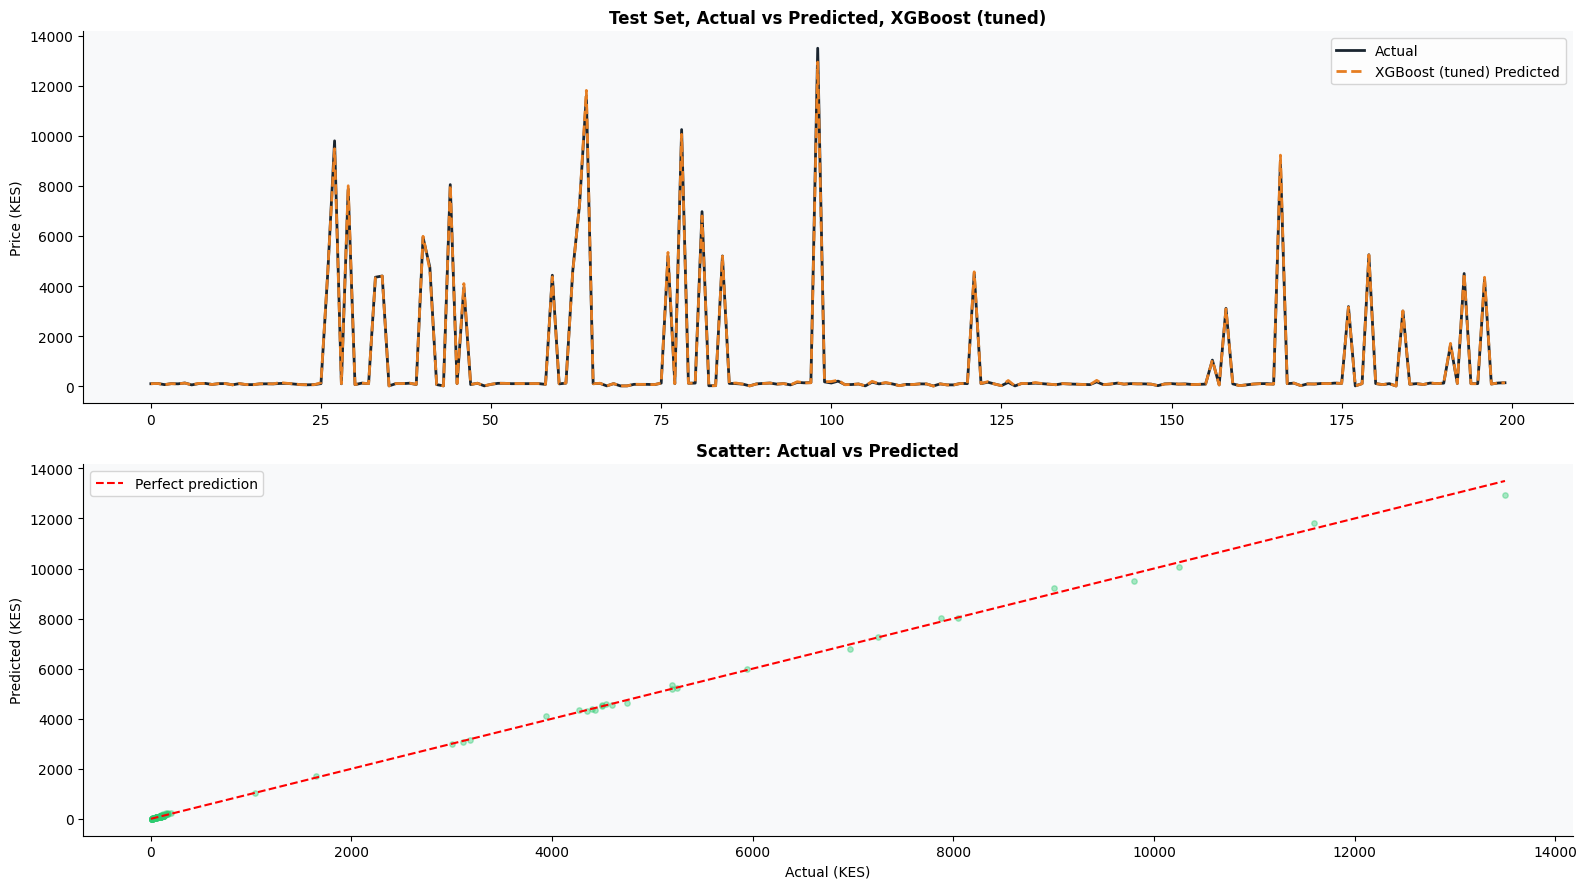

In [54]:
n_plot = min(200, len(y_test_actual))
fig, axes = plt.subplots(2, 1, figsize=(16, 9))

axes[0].plot(range(n_plot), y_test_actual[-n_plot:], label='Actual', color=SP_DARK, lw=2)
axes[0].plot(range(n_plot), y_pred_test[-n_plot:], label=f'{best_model_name} Predicted',
             color=SP_ACCENT, lw=2, linestyle='--')
axes[0].set_title(f'Test Set, Actual vs Predicted, {best_model_name}', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Price (KES)'); axes[0].legend(); axes[0].set_facecolor('#F8F9FA')

axes[1].scatter(y_test_actual[-n_plot:], y_pred_test[-n_plot:], alpha=0.4, color=SP_GREEN, s=15)
mx = max(y_test_actual[-n_plot:].max(), y_pred_test[-n_plot:].max())
axes[1].plot([0,mx],[0,mx],'r--', lw=1.5, label='Perfect prediction')
axes[1].set_title('Scatter: Actual vs Predicted', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Actual (KES)'); axes[1].set_ylabel('Predicted (KES)')
axes[1].legend(); axes[1].set_facecolor('#F8F9FA')

fig.patch.set_facecolor('white'); plt.tight_layout()
plt.savefig('viz15_test_actual_vs_predicted.png', dpi=150, bbox_inches='tight'); plt.show()

### Viz 16 - Residuals on Test Set

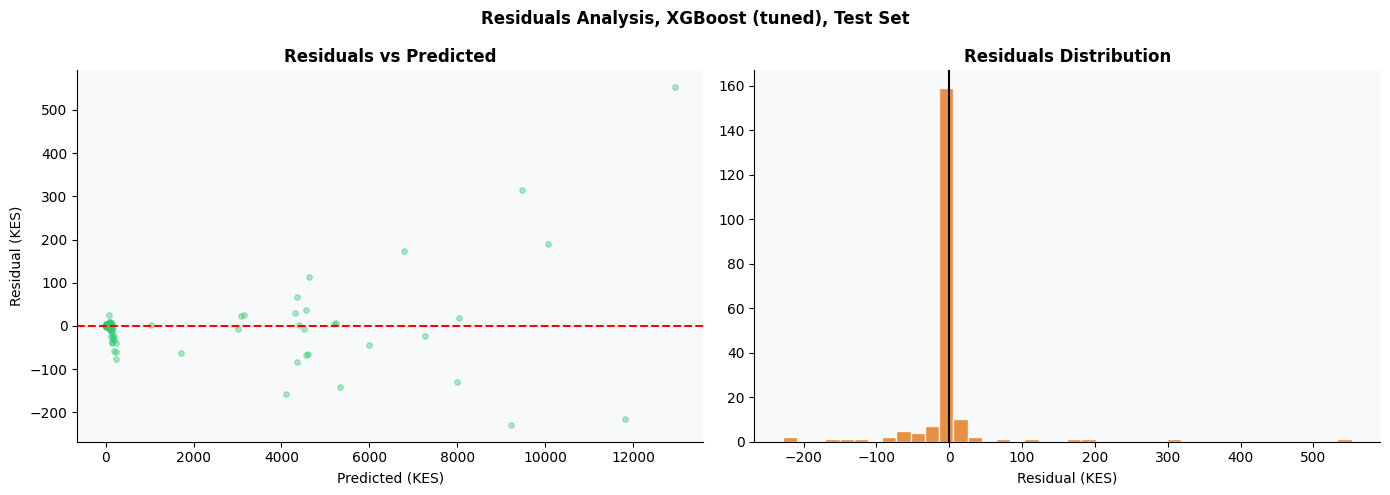

Residual mean: -0.711 KES | std: 59.045 KES


In [55]:
residuals = y_test_actual[-n_plot:] - y_pred_test[-n_plot:]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_pred_test[-n_plot:], residuals, alpha=0.4, color=SP_GREEN, s=15)
axes[0].axhline(0, color='red', linestyle='--', lw=1.5)
axes[0].set_title('Residuals vs Predicted', fontweight='bold')
axes[0].set_xlabel('Predicted (KES)'); axes[0].set_ylabel('Residual (KES)'); axes[0].set_facecolor('#F8F9FA')
axes[1].hist(residuals, bins=40, color=SP_ACCENT, edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', lw=1.5)
axes[1].set_title('Residuals Distribution', fontweight='bold')
axes[1].set_xlabel('Residual (KES)'); axes[1].set_facecolor('#F8F9FA')
fig.suptitle(f'Residuals Analysis, {best_model_name}, Test Set', fontsize=12, fontweight='bold')
fig.patch.set_facecolor('white'); plt.tight_layout()
plt.savefig('viz16_residuals.png', dpi=150, bbox_inches='tight'); plt.show()
print(f'Residual mean: {residuals.mean():.3f} KES | std: {residuals.std():.3f} KES')

### Viz 17 - Feature Importance, Best Tree-Based Model
Shown if the best model is tree based. Confirms which features actually drove the final predictions.

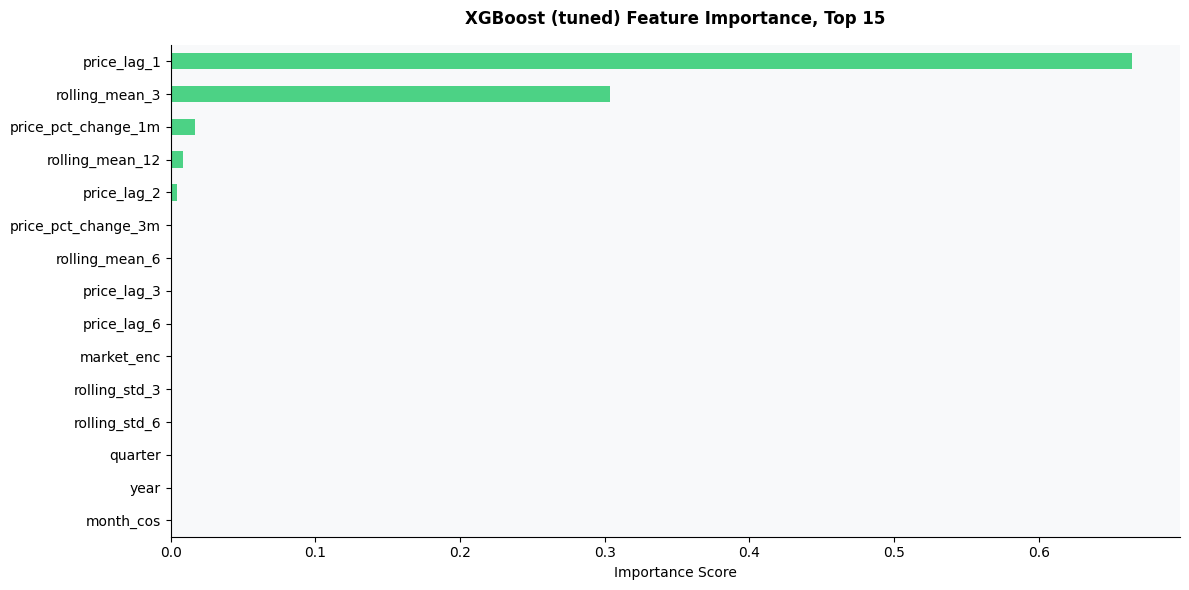

In [56]:
if best_model_name in ['XGBoost', 'XGBoost (tuned)', 'LightGBM', 'LightGBM (tuned)', 'Random Forest']:
    model = fitted_models[best_model_name]
    fi = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(12, 6))
    fi.head(15)[::-1].plot(kind='barh', ax=ax, color=SP_GREEN, alpha=0.85)
    ax.set_title(f'{best_model_name} Feature Importance, Top 15', fontsize=12, fontweight='bold', pad=15)
    ax.set_xlabel('Importance Score'); ax.set_facecolor('#F8F9FA')
    fig.patch.set_facecolor('white'); plt.tight_layout()
    plt.savefig('viz17_feature_importance.png', dpi=150, bbox_inches='tight'); plt.show()
else:
    print(f'{best_model_name} is not tree based, feature importance plot not applicable')